# CAPTCHA GAN Training
Adapted from PyTorch DCGAN Tutorial: https://docs.pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html

In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [2]:
# Root directory for dataset
dataroot = "train"

# Number of channels in the training images. For color images this is 3
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 128

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

# Create Datasets
Target resolution is 256x40 px.
Thus, resize + crop / pad all training data to this size as well.

In [3]:
import os
import random
import numpy as np
import cv2
import torch
from torch.utils.data import DataLoader
from torchvision import datasets as dset, transforms
import torchvision.transforms.functional as TF
from PIL import Image, ImageOps


class ResizePadToWidth:
    def __init__(self, target_height=80, target_width=512, grayscale=True, pad_color=255, augment=False):
        self.target_height = target_height
        self.target_width = target_width
        self.grayscale = grayscale
        self.pad_color = pad_color
        self.augment = augment

    def __call__(self, img):
        # If img is PIL.Image, convert to OpenCV NumPy array
        if isinstance(img, Image.Image):
            img = np.array(img)
            # Convert RGB to BGR for OpenCV
            if not self.grayscale and img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        H, W = img.shape[:2]

        # Resize keeping aspect ratio
        if H != self.target_height:
            new_W = int(W * (self.target_height / float(H)))
            img = cv2.resize(img, (new_W, self.target_height), interpolation=cv2.INTER_AREA)
            H, W = img.shape[:2]

        # Crop if too wide
        if W > self.target_width:
            if self.augment:
                left = random.randint(0, W - self.target_width)
            else:
                left = (W - self.target_width) // 2
            img = img[:, left:left + self.target_width]
            W = self.target_width

        # Pad if too narrow 
        pad_left = (self.target_width - W) // 2
        pad_right = self.target_width - W - pad_left
        if self.augment and self.target_width - W > 0:
            shift = random.randint(-int(0.15 * (self.target_width - W)), int(0.15 * (self.target_width - W)))
            pad_left = max(0, min(self.target_width - W, pad_left + shift))
            pad_right = self.target_width - W - pad_left

        if self.grayscale:
            if img.ndim == 3:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=self.pad_color)
        else:
            if img.ndim == 2:
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            img = cv2.copyMakeBorder(img, 0, 0, pad_left, pad_right, borderType=cv2.BORDER_CONSTANT, value=[self.pad_color]*3)

        # To tensor in [-1,1]
        img = img.astype(np.float32) / 255.0
        img = (img - 0.5) / 0.5

        if self.grayscale:
            tensor = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        else:
            tensor = torch.from_numpy(np.transpose(img, (2,0,1)))  # [3,H,W]

        return tensor


In [4]:
# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = dset.ImageFolder(
    root=dataroot,
    transform=ResizePadToWidth(target_height=40,
                                  target_width=256,
                                  grayscale=False,   # change to False for RGB
                                  pad_color=255,    # white padding
                                  augment=True)
)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)


# Prepare GPU

In [5]:
# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cuda:0


# View Dataset

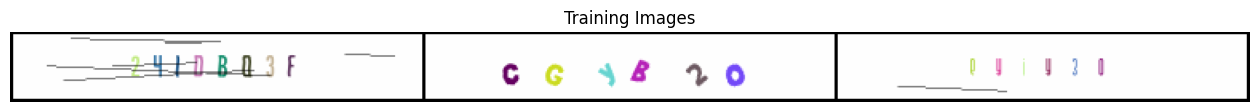

In [6]:
# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(16,16))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

# Weight Init

In [7]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator

In [8]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()

        self.main = nn.Sequential(
            # 1x1 → 5x16
            nn.ConvTranspose2d(nz, ngf*16, kernel_size=(5,16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True),

            # 5x16 → 10x32
            nn.ConvTranspose2d(ngf*16, ngf*8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 10x32 → 20x64
            nn.ConvTranspose2d(ngf*8, ngf*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 20x64 → 40x128
            nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 40x128 → 40x256 (double width only)
            nn.ConvTranspose2d(ngf*2, ngf, kernel_size=(3,4), stride=(1,2), padding=(1,1), bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # final: 40×256 → output RGB
            nn.ConvTranspose2d(ngf, nc, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

In [9]:
# Create the generator
netG = Generator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(5, 16), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(3, 4), stride=(1, 2), padding=(1, 1), bias=False)
    (13): Batch

# Discriminator

In [10]:
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # 40x256 → 20x128
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 20x128 → 10x64
            nn.Conv2d(ndf, ndf*2, 4, 2, 1),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            # 10x64 → 5x32
            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            # 5x32 → 1x1
            nn.Conv2d(ndf*4, 1, kernel_size=(5,32), stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1)  # [batch]

In [11]:
# Create the Discriminator
netD = Discriminator().to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(5, 32), stride=(1, 1))
    (9): Sigmoid()
  )
)


# Training

In [12]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.0
fake_label = 0.0

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

Starting Training Loop...
[0/200][0/157]	Loss_D: 3.2951	Loss_G: 0.0012	D(x): 0.4560	D(G(z)): 0.7010 / 0.9988
[0/200][50/157]	Loss_D: 5.1335	Loss_G: 1.6230	D(x): 0.1025	D(G(z)): 0.5944 / 0.2785
[0/200][100/157]	Loss_D: 3.1976	Loss_G: 0.8166	D(x): 0.2784	D(G(z)): 0.6842 / 0.4926
[0/200][150/157]	Loss_D: 3.2628	Loss_G: 0.1201	D(x): 0.0869	D(G(z)): 0.2634 / 0.8931


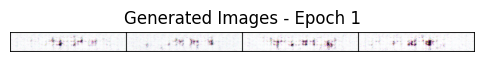

[1/200][0/157]	Loss_D: 2.8013	Loss_G: 1.4172	D(x): 0.5093	D(G(z)): 0.8157 / 0.2894
[1/200][50/157]	Loss_D: 4.2965	Loss_G: 0.0975	D(x): 0.0203	D(G(z)): 0.1486 / 0.9119
[1/200][100/157]	Loss_D: 3.4181	Loss_G: 0.0565	D(x): 0.0557	D(G(z)): 0.1157 / 0.9457
[1/200][150/157]	Loss_D: 2.4058	Loss_G: 1.4104	D(x): 0.6843	D(G(z)): 0.8390 / 0.2743


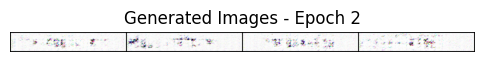

[2/200][0/157]	Loss_D: 2.0934	Loss_G: 0.3416	D(x): 0.2292	D(G(z)): 0.3331 / 0.7220
[2/200][50/157]	Loss_D: 2.2938	Loss_G: 0.2439	D(x): 0.1730	D(G(z)): 0.2937 / 0.7884
[2/200][100/157]	Loss_D: 2.2731	Loss_G: 0.1752	D(x): 0.1655	D(G(z)): 0.2516 / 0.8416
[2/200][150/157]	Loss_D: 2.3017	Loss_G: 0.1928	D(x): 0.1406	D(G(z)): 0.2016 / 0.8272


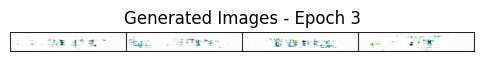

[3/200][0/157]	Loss_D: 1.7254	Loss_G: 1.2262	D(x): 0.5880	D(G(z)): 0.6686 / 0.3052
[3/200][50/157]	Loss_D: 1.9947	Loss_G: 1.1663	D(x): 0.6399	D(G(z)): 0.7701 / 0.3213
[3/200][100/157]	Loss_D: 1.7886	Loss_G: 1.2954	D(x): 0.6898	D(G(z)): 0.7444 / 0.2910
[3/200][150/157]	Loss_D: 1.9118	Loss_G: 1.2089	D(x): 0.6891	D(G(z)): 0.7567 / 0.3114


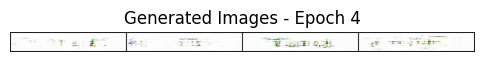

[4/200][0/157]	Loss_D: 1.4826	Loss_G: 0.4043	D(x): 0.3741	D(G(z)): 0.3341 / 0.6716
[4/200][50/157]	Loss_D: 1.8470	Loss_G: 1.7567	D(x): 0.8142	D(G(z)): 0.7921 / 0.1880
[4/200][100/157]	Loss_D: 1.8457	Loss_G: 0.3138	D(x): 0.2163	D(G(z)): 0.1942 / 0.7375
[4/200][150/157]	Loss_D: 1.9314	Loss_G: 1.5229	D(x): 0.7866	D(G(z)): 0.8014 / 0.2268


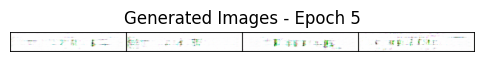

[5/200][0/157]	Loss_D: 1.4590	Loss_G: 0.4538	D(x): 0.3395	D(G(z)): 0.2765 / 0.6435
[5/200][50/157]	Loss_D: 1.2753	Loss_G: 1.2945	D(x): 0.6204	D(G(z)): 0.5279 / 0.2895
[5/200][100/157]	Loss_D: 1.6712	Loss_G: 1.1003	D(x): 0.6586	D(G(z)): 0.6841 / 0.3572
[5/200][150/157]	Loss_D: 1.7414	Loss_G: 0.4369	D(x): 0.4299	D(G(z)): 0.5371 / 0.6604


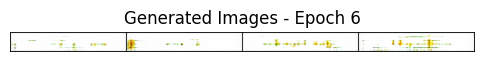

[6/200][0/157]	Loss_D: 1.3468	Loss_G: 0.5468	D(x): 0.4078	D(G(z)): 0.3095 / 0.5893
[6/200][50/157]	Loss_D: 1.5407	Loss_G: 1.4442	D(x): 0.7091	D(G(z)): 0.6766 / 0.2532
[6/200][100/157]	Loss_D: 1.6579	Loss_G: 0.4895	D(x): 0.3241	D(G(z)): 0.3677 / 0.6233
[6/200][150/157]	Loss_D: 1.4208	Loss_G: 1.1110	D(x): 0.6698	D(G(z)): 0.6233 / 0.3399


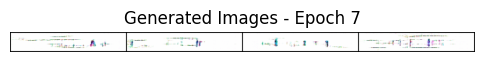

[7/200][0/157]	Loss_D: 1.6434	Loss_G: 0.3254	D(x): 0.2486	D(G(z)): 0.1751 / 0.7245
[7/200][50/157]	Loss_D: 1.4898	Loss_G: 0.9370	D(x): 0.6004	D(G(z)): 0.6036 / 0.4051
[7/200][100/157]	Loss_D: 1.6585	Loss_G: 1.1590	D(x): 0.6413	D(G(z)): 0.6783 / 0.3248
[7/200][150/157]	Loss_D: 1.7421	Loss_G: 1.2613	D(x): 0.6769	D(G(z)): 0.7222 / 0.2941


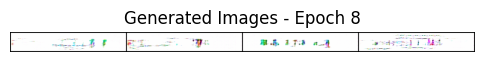

[8/200][0/157]	Loss_D: 1.2974	Loss_G: 0.7830	D(x): 0.4729	D(G(z)): 0.3999 / 0.4636
[8/200][50/157]	Loss_D: 1.5937	Loss_G: 1.0029	D(x): 0.6125	D(G(z)): 0.6543 / 0.3817
[8/200][100/157]	Loss_D: 1.5538	Loss_G: 0.4474	D(x): 0.3267	D(G(z)): 0.3218 / 0.6435
[8/200][150/157]	Loss_D: 1.7287	Loss_G: 0.3348	D(x): 0.2546	D(G(z)): 0.2713 / 0.7198


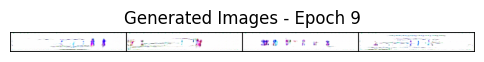

[9/200][0/157]	Loss_D: 1.5601	Loss_G: 1.4330	D(x): 0.7251	D(G(z)): 0.6987 / 0.2510
[9/200][50/157]	Loss_D: 1.2971	Loss_G: 0.8487	D(x): 0.5687	D(G(z)): 0.5022 / 0.4385
[9/200][100/157]	Loss_D: 1.4884	Loss_G: 0.3824	D(x): 0.3104	D(G(z)): 0.2458 / 0.6873
[9/200][150/157]	Loss_D: 1.6186	Loss_G: 0.3913	D(x): 0.3037	D(G(z)): 0.3198 / 0.6795


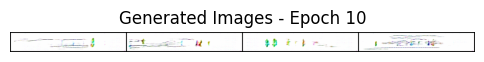

[10/200][0/157]	Loss_D: 1.6011	Loss_G: 1.1314	D(x): 0.6608	D(G(z)): 0.6756 / 0.3374
[10/200][50/157]	Loss_D: 1.3762	Loss_G: 0.3872	D(x): 0.3596	D(G(z)): 0.2578 / 0.6841
[10/200][100/157]	Loss_D: 1.5161	Loss_G: 0.4488	D(x): 0.3853	D(G(z)): 0.4004 / 0.6437
[10/200][150/157]	Loss_D: 1.4502	Loss_G: 0.6681	D(x): 0.4496	D(G(z)): 0.4581 / 0.5203


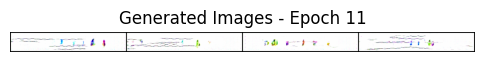

[11/200][0/157]	Loss_D: 2.0147	Loss_G: 1.5740	D(x): 0.8067	D(G(z)): 0.8250 / 0.2201
[11/200][50/157]	Loss_D: 1.5601	Loss_G: 0.3636	D(x): 0.3135	D(G(z)): 0.3090 / 0.6980
[11/200][100/157]	Loss_D: 1.6427	Loss_G: 0.3430	D(x): 0.2596	D(G(z)): 0.2276 / 0.7130
[11/200][150/157]	Loss_D: 1.6709	Loss_G: 0.3640	D(x): 0.2913	D(G(z)): 0.3178 / 0.7001


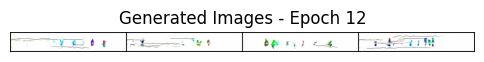

[12/200][0/157]	Loss_D: 1.6062	Loss_G: 0.9435	D(x): 0.5989	D(G(z)): 0.6527 / 0.3981
[12/200][50/157]	Loss_D: 1.4636	Loss_G: 1.2624	D(x): 0.6401	D(G(z)): 0.6290 / 0.2919
[12/200][100/157]	Loss_D: 1.5798	Loss_G: 1.3499	D(x): 0.7133	D(G(z)): 0.7044 / 0.2656
[12/200][150/157]	Loss_D: 1.5047	Loss_G: 1.1265	D(x): 0.6758	D(G(z)): 0.6628 / 0.3311


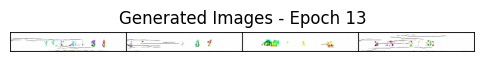

[13/200][0/157]	Loss_D: 1.5618	Loss_G: 0.5573	D(x): 0.3685	D(G(z)): 0.4097 / 0.5802
[13/200][50/157]	Loss_D: 1.4811	Loss_G: 0.4839	D(x): 0.4081	D(G(z)): 0.4247 / 0.6201
[13/200][100/157]	Loss_D: 1.7299	Loss_G: 0.3313	D(x): 0.2456	D(G(z)): 0.2544 / 0.7203
[13/200][150/157]	Loss_D: 1.5753	Loss_G: 0.3355	D(x): 0.3055	D(G(z)): 0.3030 / 0.7178


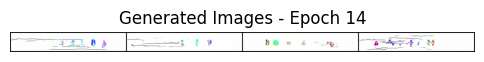

[14/200][0/157]	Loss_D: 1.5096	Loss_G: 0.8317	D(x): 0.6060	D(G(z)): 0.6138 / 0.4472
[14/200][50/157]	Loss_D: 1.6470	Loss_G: 0.3320	D(x): 0.2793	D(G(z)): 0.2955 / 0.7196
[14/200][100/157]	Loss_D: 1.6690	Loss_G: 1.3265	D(x): 0.7283	D(G(z)): 0.7351 / 0.2707
[14/200][150/157]	Loss_D: 1.5393	Loss_G: 1.2028	D(x): 0.6549	D(G(z)): 0.6659 / 0.3054


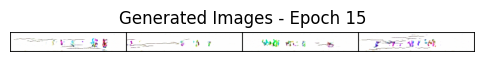

[15/200][0/157]	Loss_D: 1.5762	Loss_G: 0.3671	D(x): 0.3078	D(G(z)): 0.3079 / 0.6965
[15/200][50/157]	Loss_D: 1.6035	Loss_G: 0.4070	D(x): 0.2977	D(G(z)): 0.2995 / 0.6688
[15/200][100/157]	Loss_D: 1.4963	Loss_G: 1.1649	D(x): 0.6333	D(G(z)): 0.6381 / 0.3210
[15/200][150/157]	Loss_D: 1.5335	Loss_G: 1.1651	D(x): 0.6501	D(G(z)): 0.6602 / 0.3172


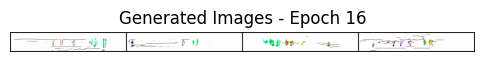

[16/200][0/157]	Loss_D: 1.6240	Loss_G: 0.3756	D(x): 0.2788	D(G(z)): 0.2754 / 0.6903
[16/200][50/157]	Loss_D: 1.5488	Loss_G: 0.3948	D(x): 0.3260	D(G(z)): 0.3256 / 0.6782
[16/200][100/157]	Loss_D: 1.6033	Loss_G: 0.2928	D(x): 0.2776	D(G(z)): 0.2515 / 0.7483
[16/200][150/157]	Loss_D: 1.4786	Loss_G: 1.0776	D(x): 0.6388	D(G(z)): 0.6316 / 0.3504


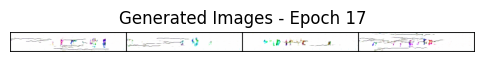

[17/200][0/157]	Loss_D: 1.6784	Loss_G: 0.3318	D(x): 0.2599	D(G(z)): 0.2656 / 0.7194
[17/200][50/157]	Loss_D: 1.6428	Loss_G: 0.2849	D(x): 0.2737	D(G(z)): 0.2674 / 0.7551
[17/200][100/157]	Loss_D: 1.4249	Loss_G: 0.5330	D(x): 0.4116	D(G(z)): 0.4064 / 0.5907
[17/200][150/157]	Loss_D: 1.5523	Loss_G: 1.1090	D(x): 0.6011	D(G(z)): 0.6377 / 0.3362


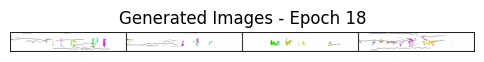

[18/200][0/157]	Loss_D: 1.4099	Loss_G: 0.6169	D(x): 0.4092	D(G(z)): 0.3900 / 0.5445
[18/200][50/157]	Loss_D: 1.4399	Loss_G: 0.6534	D(x): 0.4440	D(G(z)): 0.4550 / 0.5262
[18/200][100/157]	Loss_D: 1.5545	Loss_G: 0.4206	D(x): 0.3473	D(G(z)): 0.3789 / 0.6592
[18/200][150/157]	Loss_D: 1.6758	Loss_G: 1.4150	D(x): 0.7049	D(G(z)): 0.7280 / 0.2476


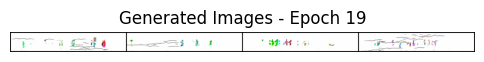

[19/200][0/157]	Loss_D: 1.4764	Loss_G: 0.5403	D(x): 0.3793	D(G(z)): 0.3817 / 0.5863
[19/200][50/157]	Loss_D: 1.5876	Loss_G: 0.3798	D(x): 0.2999	D(G(z)): 0.3007 / 0.6867
[19/200][100/157]	Loss_D: 1.5236	Loss_G: 0.6247	D(x): 0.3969	D(G(z)): 0.4343 / 0.5391
[19/200][150/157]	Loss_D: 1.6037	Loss_G: 1.4558	D(x): 0.6532	D(G(z)): 0.6826 / 0.2375


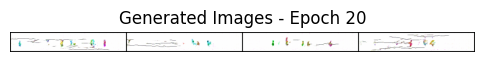

[20/200][0/157]	Loss_D: 1.5027	Loss_G: 0.4619	D(x): 0.3456	D(G(z)): 0.3410 / 0.6326
[20/200][50/157]	Loss_D: 1.5128	Loss_G: 0.4402	D(x): 0.3266	D(G(z)): 0.3130 / 0.6464
[20/200][100/157]	Loss_D: 1.4187	Loss_G: 0.8234	D(x): 0.5151	D(G(z)): 0.5188 / 0.4455
[20/200][150/157]	Loss_D: 1.4826	Loss_G: 1.0471	D(x): 0.6343	D(G(z)): 0.6342 / 0.3565


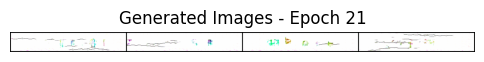

[21/200][0/157]	Loss_D: 1.4700	Loss_G: 0.6188	D(x): 0.3852	D(G(z)): 0.3849 / 0.5456
[21/200][50/157]	Loss_D: 1.5391	Loss_G: 1.1313	D(x): 0.6961	D(G(z)): 0.6873 / 0.3268
[21/200][100/157]	Loss_D: 1.5653	Loss_G: 0.4686	D(x): 0.3298	D(G(z)): 0.3531 / 0.6292
[21/200][150/157]	Loss_D: 1.5025	Loss_G: 0.5481	D(x): 0.3966	D(G(z)): 0.4230 / 0.5821


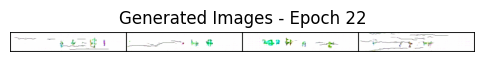

[22/200][0/157]	Loss_D: 1.6353	Loss_G: 1.1503	D(x): 0.6912	D(G(z)): 0.7116 / 0.3235
[22/200][50/157]	Loss_D: 1.5788	Loss_G: 1.1922	D(x): 0.6710	D(G(z)): 0.6839 / 0.3097
[22/200][100/157]	Loss_D: 1.6271	Loss_G: 1.2668	D(x): 0.7006	D(G(z)): 0.7095 / 0.2908
[22/200][150/157]	Loss_D: 1.6592	Loss_G: 0.3241	D(x): 0.2641	D(G(z)): 0.2662 / 0.7248


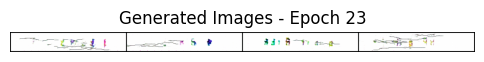

[23/200][0/157]	Loss_D: 1.6389	Loss_G: 1.3836	D(x): 0.6968	D(G(z)): 0.7156 / 0.2572
[23/200][50/157]	Loss_D: 1.4555	Loss_G: 0.7814	D(x): 0.5170	D(G(z)): 0.5359 / 0.4613
[23/200][100/157]	Loss_D: 1.7168	Loss_G: 0.3071	D(x): 0.2464	D(G(z)): 0.2553 / 0.7371
[23/200][150/157]	Loss_D: 1.4268	Loss_G: 0.4997	D(x): 0.3880	D(G(z)): 0.3643 / 0.6125


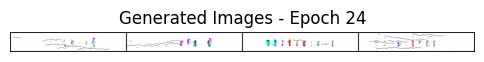

[24/200][0/157]	Loss_D: 1.6608	Loss_G: 1.3028	D(x): 0.6755	D(G(z)): 0.7126 / 0.2775
[24/200][50/157]	Loss_D: 1.4744	Loss_G: 1.0385	D(x): 0.6110	D(G(z)): 0.6173 / 0.3582
[24/200][100/157]	Loss_D: 1.5780	Loss_G: 1.1595	D(x): 0.6653	D(G(z)): 0.6842 / 0.3195
[24/200][150/157]	Loss_D: 1.6253	Loss_G: 1.2270	D(x): 0.7061	D(G(z)): 0.7162 / 0.2967


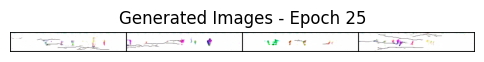

[25/200][0/157]	Loss_D: 1.5255	Loss_G: 0.4199	D(x): 0.3269	D(G(z)): 0.3075 / 0.6617
[25/200][50/157]	Loss_D: 1.5780	Loss_G: 0.4172	D(x): 0.3127	D(G(z)): 0.3180 / 0.6626
[25/200][100/157]	Loss_D: 1.5481	Loss_G: 1.0527	D(x): 0.6383	D(G(z)): 0.6535 / 0.3602
[25/200][150/157]	Loss_D: 1.5160	Loss_G: 1.2972	D(x): 0.6717	D(G(z)): 0.6670 / 0.2801


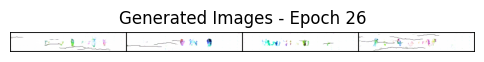

[26/200][0/157]	Loss_D: 1.5100	Loss_G: 0.4055	D(x): 0.3365	D(G(z)): 0.3227 / 0.6697
[26/200][50/157]	Loss_D: 1.3683	Loss_G: 0.7597	D(x): 0.4685	D(G(z)): 0.4463 / 0.4722
[26/200][100/157]	Loss_D: 1.5560	Loss_G: 0.9203	D(x): 0.5952	D(G(z)): 0.6352 / 0.4039
[26/200][150/157]	Loss_D: 1.5363	Loss_G: 0.4037	D(x): 0.3316	D(G(z)): 0.3335 / 0.6720


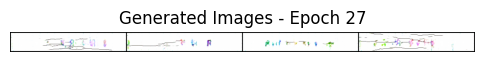

[27/200][0/157]	Loss_D: 1.4750	Loss_G: 0.8960	D(x): 0.6100	D(G(z)): 0.6133 / 0.4213
[27/200][50/157]	Loss_D: 1.3973	Loss_G: 0.9178	D(x): 0.5528	D(G(z)): 0.5444 / 0.4047
[27/200][100/157]	Loss_D: 1.4931	Loss_G: 1.1760	D(x): 0.6654	D(G(z)): 0.6542 / 0.3125
[27/200][150/157]	Loss_D: 1.4060	Loss_G: 0.7740	D(x): 0.5205	D(G(z)): 0.5208 / 0.4661


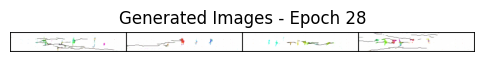

[28/200][0/157]	Loss_D: 1.4373	Loss_G: 0.5523	D(x): 0.4520	D(G(z)): 0.4605 / 0.5802
[28/200][50/157]	Loss_D: 1.5484	Loss_G: 0.3996	D(x): 0.3087	D(G(z)): 0.2988 / 0.6731
[28/200][100/157]	Loss_D: 1.4576	Loss_G: 0.4973	D(x): 0.4023	D(G(z)): 0.4096 / 0.6117
[28/200][150/157]	Loss_D: 1.4668	Loss_G: 0.5429	D(x): 0.3993	D(G(z)): 0.4058 / 0.5846


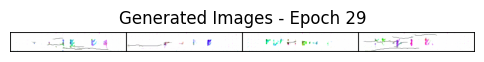

[29/200][0/157]	Loss_D: 1.5964	Loss_G: 1.2391	D(x): 0.7031	D(G(z)): 0.7082 / 0.2937
[29/200][50/157]	Loss_D: 1.4996	Loss_G: 1.0593	D(x): 0.6589	D(G(z)): 0.6526 / 0.3538
[29/200][100/157]	Loss_D: 1.3946	Loss_G: 0.5525	D(x): 0.4266	D(G(z)): 0.4006 / 0.5832
[29/200][150/157]	Loss_D: 1.5317	Loss_G: 0.5266	D(x): 0.3623	D(G(z)): 0.3815 / 0.5952


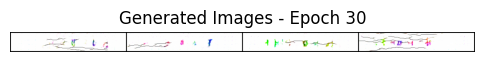

[30/200][0/157]	Loss_D: 1.5257	Loss_G: 1.2027	D(x): 0.6396	D(G(z)): 0.6514 / 0.3056
[30/200][50/157]	Loss_D: 1.3797	Loss_G: 0.8264	D(x): 0.5246	D(G(z)): 0.5085 / 0.4434
[30/200][100/157]	Loss_D: 1.5031	Loss_G: 1.3334	D(x): 0.7306	D(G(z)): 0.6886 / 0.2715
[30/200][150/157]	Loss_D: 1.5533	Loss_G: 1.4253	D(x): 0.6765	D(G(z)): 0.6779 / 0.2461


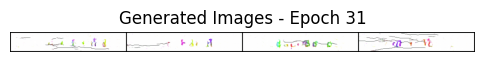

[31/200][0/157]	Loss_D: 1.3961	Loss_G: 0.9837	D(x): 0.5252	D(G(z)): 0.5142 / 0.3802
[31/200][50/157]	Loss_D: 1.4524	Loss_G: 0.8057	D(x): 0.5214	D(G(z)): 0.5384 / 0.4535
[31/200][100/157]	Loss_D: 1.5496	Loss_G: 1.0140	D(x): 0.6130	D(G(z)): 0.6408 / 0.3675
[31/200][150/157]	Loss_D: 1.4820	Loss_G: 1.2430	D(x): 0.6951	D(G(z)): 0.6668 / 0.2944


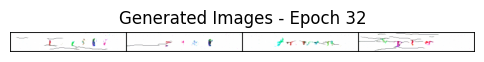

[32/200][0/157]	Loss_D: 1.4671	Loss_G: 0.3906	D(x): 0.3600	D(G(z)): 0.3431 / 0.6809
[32/200][50/157]	Loss_D: 1.5518	Loss_G: 1.2373	D(x): 0.6642	D(G(z)): 0.6751 / 0.2976
[32/200][100/157]	Loss_D: 1.5392	Loss_G: 1.1379	D(x): 0.6535	D(G(z)): 0.6635 / 0.3266
[32/200][150/157]	Loss_D: 1.5274	Loss_G: 1.2730	D(x): 0.7092	D(G(z)): 0.6873 / 0.2872


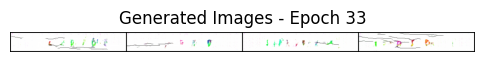

[33/200][0/157]	Loss_D: 1.3788	Loss_G: 0.4491	D(x): 0.3795	D(G(z)): 0.3234 / 0.6421
[33/200][50/157]	Loss_D: 1.4390	Loss_G: 0.4839	D(x): 0.4058	D(G(z)): 0.4024 / 0.6190
[33/200][100/157]	Loss_D: 1.5202	Loss_G: 0.4031	D(x): 0.3198	D(G(z)): 0.2979 / 0.6707
[33/200][150/157]	Loss_D: 1.4478	Loss_G: 0.5171	D(x): 0.3754	D(G(z)): 0.3554 / 0.5996


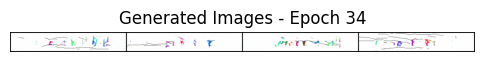

[34/200][0/157]	Loss_D: 1.4981	Loss_G: 1.0817	D(x): 0.6239	D(G(z)): 0.6313 / 0.3449
[34/200][50/157]	Loss_D: 1.4880	Loss_G: 0.4366	D(x): 0.3566	D(G(z)): 0.3493 / 0.6488
[34/200][100/157]	Loss_D: 1.4554	Loss_G: 1.0350	D(x): 0.6491	D(G(z)): 0.6310 / 0.3621
[34/200][150/157]	Loss_D: 1.3657	Loss_G: 0.5985	D(x): 0.4674	D(G(z)): 0.4416 / 0.5558


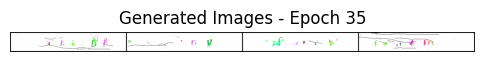

[35/200][0/157]	Loss_D: 1.6684	Loss_G: 1.2437	D(x): 0.7470	D(G(z)): 0.7408 / 0.2954
[35/200][50/157]	Loss_D: 1.7163	Loss_G: 0.3560	D(x): 0.2477	D(G(z)): 0.2588 / 0.7023
[35/200][100/157]	Loss_D: 1.3726	Loss_G: 0.8630	D(x): 0.5745	D(G(z)): 0.5507 / 0.4256
[35/200][150/157]	Loss_D: 1.5773	Loss_G: 0.4084	D(x): 0.3055	D(G(z)): 0.3019 / 0.6674


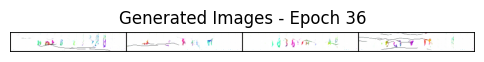

[36/200][0/157]	Loss_D: 1.3577	Loss_G: 0.8198	D(x): 0.5646	D(G(z)): 0.5326 / 0.4474
[36/200][50/157]	Loss_D: 1.4556	Loss_G: 0.6205	D(x): 0.4191	D(G(z)): 0.4250 / 0.5414
[36/200][100/157]	Loss_D: 1.5207	Loss_G: 1.2376	D(x): 0.7096	D(G(z)): 0.6841 / 0.2968
[36/200][150/157]	Loss_D: 1.4448	Loss_G: 1.1050	D(x): 0.6994	D(G(z)): 0.6551 / 0.3406


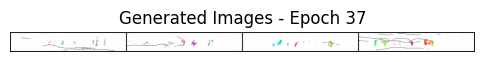

[37/200][0/157]	Loss_D: 1.4209	Loss_G: 0.5320	D(x): 0.4061	D(G(z)): 0.3882 / 0.5955
[37/200][50/157]	Loss_D: 1.3920	Loss_G: 0.8657	D(x): 0.5959	D(G(z)): 0.5754 / 0.4275
[37/200][100/157]	Loss_D: 1.4070	Loss_G: 0.8470	D(x): 0.5840	D(G(z)): 0.5708 / 0.4348
[37/200][150/157]	Loss_D: 1.4334	Loss_G: 0.5187	D(x): 0.4159	D(G(z)): 0.4172 / 0.5989


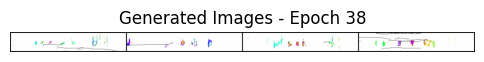

[38/200][0/157]	Loss_D: 1.5644	Loss_G: 1.3868	D(x): 0.7352	D(G(z)): 0.7076 / 0.2615
[38/200][50/157]	Loss_D: 1.4350	Loss_G: 0.5311	D(x): 0.3932	D(G(z)): 0.3744 / 0.5937
[38/200][100/157]	Loss_D: 1.4008	Loss_G: 1.0120	D(x): 0.6526	D(G(z)): 0.6136 / 0.3692
[38/200][150/157]	Loss_D: 1.3811	Loss_G: 0.9729	D(x): 0.5965	D(G(z)): 0.5680 / 0.3850


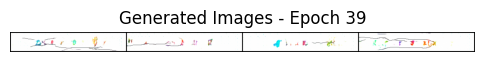

[39/200][0/157]	Loss_D: 1.4359	Loss_G: 0.5041	D(x): 0.3695	D(G(z)): 0.3335 / 0.6137
[39/200][50/157]	Loss_D: 1.3375	Loss_G: 0.8023	D(x): 0.5456	D(G(z)): 0.5064 / 0.4545
[39/200][100/157]	Loss_D: 1.5178	Loss_G: 0.4373	D(x): 0.3254	D(G(z)): 0.3105 / 0.6491
[39/200][150/157]	Loss_D: 1.4334	Loss_G: 0.4914	D(x): 0.3930	D(G(z)): 0.3746 / 0.6196


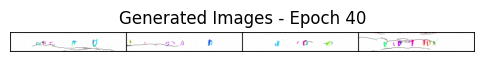

[40/200][0/157]	Loss_D: 1.4238	Loss_G: 0.9850	D(x): 0.6560	D(G(z)): 0.6237 / 0.3838
[40/200][50/157]	Loss_D: 1.5191	Loss_G: 0.4297	D(x): 0.3077	D(G(z)): 0.2692 / 0.6531
[40/200][100/157]	Loss_D: 1.4189	Loss_G: 0.9675	D(x): 0.5651	D(G(z)): 0.5546 / 0.3879
[40/200][150/157]	Loss_D: 1.5148	Loss_G: 1.4026	D(x): 0.7083	D(G(z)): 0.6829 / 0.2546


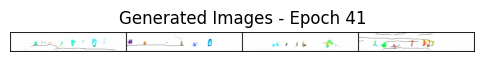

[41/200][0/157]	Loss_D: 1.3990	Loss_G: 0.7106	D(x): 0.4906	D(G(z)): 0.4670 / 0.5035
[41/200][50/157]	Loss_D: 1.5697	Loss_G: 0.4260	D(x): 0.3188	D(G(z)): 0.3233 / 0.6586
[41/200][100/157]	Loss_D: 1.6726	Loss_G: 0.3473	D(x): 0.2717	D(G(z)): 0.2809 / 0.7126
[41/200][150/157]	Loss_D: 1.3871	Loss_G: 0.8870	D(x): 0.5387	D(G(z)): 0.5231 / 0.4207


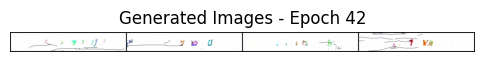

[42/200][0/157]	Loss_D: 1.3408	Loss_G: 0.8365	D(x): 0.5040	D(G(z)): 0.4620 / 0.4473
[42/200][50/157]	Loss_D: 1.3632	Loss_G: 0.7645	D(x): 0.5141	D(G(z)): 0.4839 / 0.4725
[42/200][100/157]	Loss_D: 1.3212	Loss_G: 0.9537	D(x): 0.5880	D(G(z)): 0.5323 / 0.3942
[42/200][150/157]	Loss_D: 1.5315	Loss_G: 0.3667	D(x): 0.3101	D(G(z)): 0.2832 / 0.6968


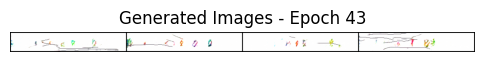

[43/200][0/157]	Loss_D: 1.4191	Loss_G: 0.9414	D(x): 0.5878	D(G(z)): 0.5771 / 0.4015
[43/200][50/157]	Loss_D: 1.5184	Loss_G: 1.3513	D(x): 0.7604	D(G(z)): 0.7017 / 0.2686
[43/200][100/157]	Loss_D: 1.2939	Loss_G: 0.9485	D(x): 0.5725	D(G(z)): 0.5119 / 0.3959
[43/200][150/157]	Loss_D: 1.4309	Loss_G: 1.2692	D(x): 0.6857	D(G(z)): 0.6418 / 0.2907


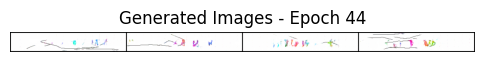

[44/200][0/157]	Loss_D: 1.4371	Loss_G: 0.4710	D(x): 0.3403	D(G(z)): 0.2744 / 0.6279
[44/200][50/157]	Loss_D: 1.4233	Loss_G: 1.3014	D(x): 0.6975	D(G(z)): 0.6470 / 0.2828
[44/200][100/157]	Loss_D: 1.3945	Loss_G: 0.8610	D(x): 0.5280	D(G(z)): 0.5160 / 0.4444
[44/200][150/157]	Loss_D: 1.3325	Loss_G: 0.6520	D(x): 0.4119	D(G(z)): 0.3475 / 0.5271


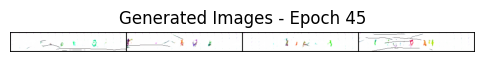

[45/200][0/157]	Loss_D: 1.6186	Loss_G: 1.5970	D(x): 0.7412	D(G(z)): 0.7239 / 0.2125
[45/200][50/157]	Loss_D: 1.6513	Loss_G: 0.3448	D(x): 0.2499	D(G(z)): 0.2054 / 0.7129
[45/200][100/157]	Loss_D: 1.6406	Loss_G: 0.3695	D(x): 0.2504	D(G(z)): 0.2040 / 0.6938
[45/200][150/157]	Loss_D: 1.4113	Loss_G: 1.0519	D(x): 0.5569	D(G(z)): 0.5429 / 0.3662


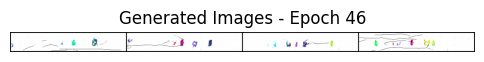

[46/200][0/157]	Loss_D: 1.4263	Loss_G: 0.4360	D(x): 0.3572	D(G(z)): 0.2981 / 0.6528
[46/200][50/157]	Loss_D: 1.3339	Loss_G: 0.9705	D(x): 0.5516	D(G(z)): 0.5074 / 0.3932
[46/200][100/157]	Loss_D: 1.3786	Loss_G: 1.1971	D(x): 0.6944	D(G(z)): 0.6257 / 0.3093
[46/200][150/157]	Loss_D: 1.4137	Loss_G: 1.1742	D(x): 0.5824	D(G(z)): 0.5603 / 0.3263


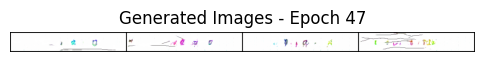

[47/200][0/157]	Loss_D: 1.2754	Loss_G: 0.6082	D(x): 0.4094	D(G(z)): 0.2960 / 0.5495
[47/200][50/157]	Loss_D: 1.3083	Loss_G: 0.9967	D(x): 0.5748	D(G(z)): 0.5130 / 0.3814
[47/200][100/157]	Loss_D: 1.5841	Loss_G: 1.8833	D(x): 0.7625	D(G(z)): 0.7158 / 0.1652
[47/200][150/157]	Loss_D: 1.2933	Loss_G: 1.0544	D(x): 0.6341	D(G(z)): 0.5504 / 0.3613


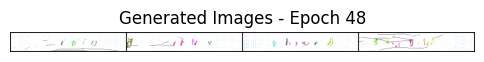

[48/200][0/157]	Loss_D: 1.4944	Loss_G: 0.3374	D(x): 0.2897	D(G(z)): 0.1755 / 0.7196
[48/200][50/157]	Loss_D: 1.7158	Loss_G: 1.6548	D(x): 0.8356	D(G(z)): 0.7738 / 0.2087
[48/200][100/157]	Loss_D: 1.5910	Loss_G: 0.6347	D(x): 0.3393	D(G(z)): 0.3535 / 0.5441
[48/200][150/157]	Loss_D: 1.6288	Loss_G: 0.3404	D(x): 0.2767	D(G(z)): 0.2217 / 0.7150


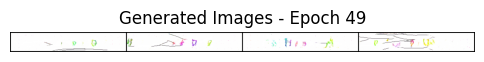

[49/200][0/157]	Loss_D: 1.4286	Loss_G: 1.4719	D(x): 0.7355	D(G(z)): 0.6598 / 0.2431
[49/200][50/157]	Loss_D: 1.2290	Loss_G: 1.2385	D(x): 0.7054	D(G(z)): 0.5754 / 0.3008
[49/200][100/157]	Loss_D: 1.4638	Loss_G: 1.4653	D(x): 0.7490	D(G(z)): 0.6792 / 0.2475
[49/200][150/157]	Loss_D: 1.3154	Loss_G: 0.4714	D(x): 0.3854	D(G(z)): 0.2765 / 0.6288


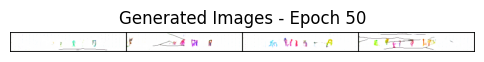

[50/200][0/157]	Loss_D: 1.3278	Loss_G: 1.3039	D(x): 0.6687	D(G(z)): 0.5765 / 0.2955
[50/200][50/157]	Loss_D: 1.1795	Loss_G: 0.7811	D(x): 0.5221	D(G(z)): 0.3906 / 0.4684
[50/200][100/157]	Loss_D: 1.1500	Loss_G: 0.8351	D(x): 0.5317	D(G(z)): 0.3829 / 0.4493
[50/200][150/157]	Loss_D: 1.3690	Loss_G: 0.5479	D(x): 0.4147	D(G(z)): 0.3584 / 0.5844


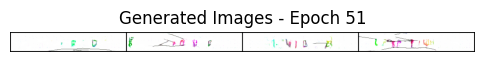

[51/200][0/157]	Loss_D: 1.6040	Loss_G: 1.2300	D(x): 0.7897	D(G(z)): 0.7313 / 0.3000
[51/200][50/157]	Loss_D: 1.3841	Loss_G: 1.3109	D(x): 0.7605	D(G(z)): 0.6525 / 0.2798
[51/200][100/157]	Loss_D: 1.2690	Loss_G: 0.5251	D(x): 0.4081	D(G(z)): 0.2853 / 0.5983
[51/200][150/157]	Loss_D: 1.5008	Loss_G: 0.3938	D(x): 0.3265	D(G(z)): 0.2651 / 0.6832


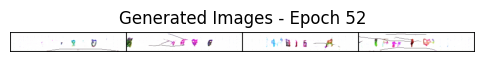

[52/200][0/157]	Loss_D: 1.3965	Loss_G: 1.2336	D(x): 0.6923	D(G(z)): 0.6204 / 0.3176
[52/200][50/157]	Loss_D: 1.2522	Loss_G: 1.3243	D(x): 0.7134	D(G(z)): 0.5811 / 0.2784
[52/200][100/157]	Loss_D: 1.2272	Loss_G: 0.8805	D(x): 0.5768	D(G(z)): 0.4723 / 0.4266
[52/200][150/157]	Loss_D: 1.3559	Loss_G: 1.1677	D(x): 0.6740	D(G(z)): 0.5992 / 0.3241


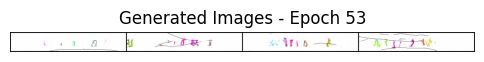

[53/200][0/157]	Loss_D: 1.3929	Loss_G: 0.4743	D(x): 0.3357	D(G(z)): 0.2103 / 0.6319
[53/200][50/157]	Loss_D: 1.2796	Loss_G: 1.1292	D(x): 0.5957	D(G(z)): 0.5058 / 0.3415
[53/200][100/157]	Loss_D: 1.1414	Loss_G: 0.9028	D(x): 0.5743	D(G(z)): 0.4271 / 0.4168
[53/200][150/157]	Loss_D: 1.2801	Loss_G: 0.9476	D(x): 0.5563	D(G(z)): 0.4670 / 0.4042


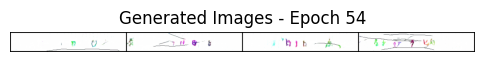

[54/200][0/157]	Loss_D: 1.4007	Loss_G: 1.4736	D(x): 0.7137	D(G(z)): 0.6285 / 0.2481
[54/200][50/157]	Loss_D: 1.1531	Loss_G: 0.6497	D(x): 0.4628	D(G(z)): 0.2718 / 0.5319
[54/200][100/157]	Loss_D: 1.3447	Loss_G: 1.4135	D(x): 0.7405	D(G(z)): 0.6303 / 0.2541
[54/200][150/157]	Loss_D: 1.3902	Loss_G: 1.4879	D(x): 0.7358	D(G(z)): 0.6458 / 0.2432


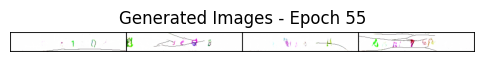

[55/200][0/157]	Loss_D: 1.4492	Loss_G: 0.4153	D(x): 0.3353	D(G(z)): 0.2284 / 0.6717
[55/200][50/157]	Loss_D: 1.2333	Loss_G: 0.6010	D(x): 0.4661	D(G(z)): 0.3403 / 0.5595
[55/200][100/157]	Loss_D: 1.2875	Loss_G: 0.6061	D(x): 0.4427	D(G(z)): 0.3419 / 0.5630
[55/200][150/157]	Loss_D: 1.2261	Loss_G: 1.6250	D(x): 0.7572	D(G(z)): 0.5976 / 0.2067


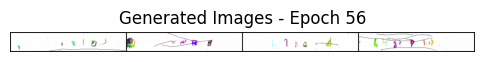

[56/200][0/157]	Loss_D: 1.2265	Loss_G: 0.7593	D(x): 0.4848	D(G(z)): 0.3544 / 0.4933
[56/200][50/157]	Loss_D: 1.1805	Loss_G: 0.5965	D(x): 0.4594	D(G(z)): 0.2973 / 0.5625
[56/200][100/157]	Loss_D: 1.3834	Loss_G: 0.4043	D(x): 0.3267	D(G(z)): 0.1932 / 0.6789
[56/200][150/157]	Loss_D: 1.4673	Loss_G: 0.4621	D(x): 0.3313	D(G(z)): 0.2580 / 0.6458


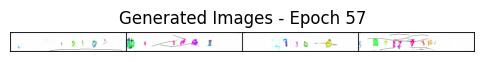

[57/200][0/157]	Loss_D: 1.2032	Loss_G: 0.8682	D(x): 0.5828	D(G(z)): 0.4538 / 0.4392
[57/200][50/157]	Loss_D: 1.2224	Loss_G: 0.4631	D(x): 0.3886	D(G(z)): 0.2044 / 0.6418
[57/200][100/157]	Loss_D: 1.5072	Loss_G: 0.5532	D(x): 0.3046	D(G(z)): 0.2214 / 0.5911
[57/200][150/157]	Loss_D: 1.2599	Loss_G: 1.4973	D(x): 0.7939	D(G(z)): 0.6261 / 0.2418


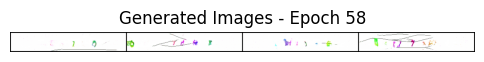

[58/200][0/157]	Loss_D: 1.2908	Loss_G: 0.6269	D(x): 0.3672	D(G(z)): 0.1990 / 0.5512
[58/200][50/157]	Loss_D: 1.2370	Loss_G: 1.0532	D(x): 0.6708	D(G(z)): 0.5403 / 0.3622
[58/200][100/157]	Loss_D: 1.4718	Loss_G: 0.5560	D(x): 0.3259	D(G(z)): 0.2349 / 0.5834
[58/200][150/157]	Loss_D: 1.2166	Loss_G: 0.7837	D(x): 0.5451	D(G(z)): 0.4298 / 0.4735


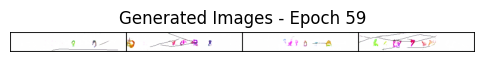

[59/200][0/157]	Loss_D: 1.5995	Loss_G: 2.5056	D(x): 0.8476	D(G(z)): 0.7307 / 0.0984
[59/200][50/157]	Loss_D: 1.2069	Loss_G: 0.6816	D(x): 0.4671	D(G(z)): 0.3049 / 0.5299
[59/200][100/157]	Loss_D: 1.2904	Loss_G: 0.5136	D(x): 0.3824	D(G(z)): 0.2201 / 0.6153
[59/200][150/157]	Loss_D: 1.0110	Loss_G: 1.0044	D(x): 0.6179	D(G(z)): 0.3856 / 0.3816


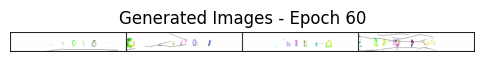

[60/200][0/157]	Loss_D: 1.2745	Loss_G: 1.8395	D(x): 0.8326	D(G(z)): 0.6443 / 0.1830
[60/200][50/157]	Loss_D: 1.3223	Loss_G: 0.5452	D(x): 0.3593	D(G(z)): 0.2078 / 0.5957
[60/200][100/157]	Loss_D: 1.3424	Loss_G: 0.5123	D(x): 0.3556	D(G(z)): 0.2155 / 0.6113
[60/200][150/157]	Loss_D: 1.1248	Loss_G: 1.3366	D(x): 0.7224	D(G(z)): 0.5191 / 0.2780


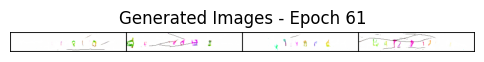

[61/200][0/157]	Loss_D: 1.1769	Loss_G: 0.5382	D(x): 0.4075	D(G(z)): 0.1982 / 0.5983
[61/200][50/157]	Loss_D: 1.1872	Loss_G: 1.3829	D(x): 0.6957	D(G(z)): 0.5372 / 0.2795
[61/200][100/157]	Loss_D: 1.1914	Loss_G: 0.6687	D(x): 0.4737	D(G(z)): 0.3310 / 0.5318
[61/200][150/157]	Loss_D: 1.2210	Loss_G: 0.4738	D(x): 0.3960	D(G(z)): 0.1978 / 0.6379


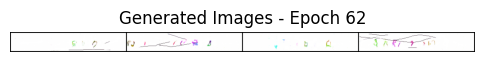

[62/200][0/157]	Loss_D: 1.2441	Loss_G: 0.4425	D(x): 0.4271	D(G(z)): 0.2733 / 0.6529
[62/200][50/157]	Loss_D: 1.1213	Loss_G: 0.8620	D(x): 0.4786	D(G(z)): 0.2768 / 0.4419
[62/200][100/157]	Loss_D: 1.1801	Loss_G: 0.8504	D(x): 0.6251	D(G(z)): 0.4819 / 0.4499
[62/200][150/157]	Loss_D: 1.4718	Loss_G: 0.3993	D(x): 0.2849	D(G(z)): 0.1314 / 0.6840


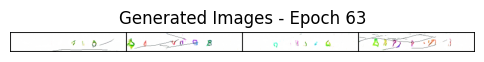

[63/200][0/157]	Loss_D: 1.0799	Loss_G: 1.5851	D(x): 0.6576	D(G(z)): 0.4480 / 0.2342
[63/200][50/157]	Loss_D: 0.9622	Loss_G: 1.2321	D(x): 0.6662	D(G(z)): 0.3985 / 0.3220
[63/200][100/157]	Loss_D: 1.1172	Loss_G: 1.3660	D(x): 0.6962	D(G(z)): 0.4963 / 0.2796
[63/200][150/157]	Loss_D: 1.3494	Loss_G: 2.0680	D(x): 0.8360	D(G(z)): 0.6684 / 0.1446


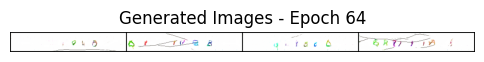

[64/200][0/157]	Loss_D: 1.1211	Loss_G: 0.7941	D(x): 0.4837	D(G(z)): 0.2878 / 0.4724
[64/200][50/157]	Loss_D: 1.3611	Loss_G: 0.3850	D(x): 0.3808	D(G(z)): 0.2445 / 0.6949
[64/200][100/157]	Loss_D: 1.0030	Loss_G: 0.7984	D(x): 0.5217	D(G(z)): 0.2612 / 0.4734
[64/200][150/157]	Loss_D: 1.6421	Loss_G: 1.9086	D(x): 0.8710	D(G(z)): 0.7544 / 0.1591


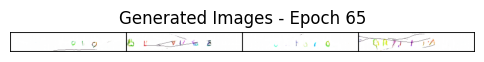

[65/200][0/157]	Loss_D: 1.3808	Loss_G: 0.5179	D(x): 0.3184	D(G(z)): 0.1461 / 0.6211
[65/200][50/157]	Loss_D: 0.8855	Loss_G: 1.1792	D(x): 0.6471	D(G(z)): 0.3309 / 0.3294
[65/200][100/157]	Loss_D: 1.0358	Loss_G: 1.3538	D(x): 0.6817	D(G(z)): 0.4425 / 0.3030
[65/200][150/157]	Loss_D: 1.4968	Loss_G: 3.0350	D(x): 0.8703	D(G(z)): 0.6973 / 0.0536


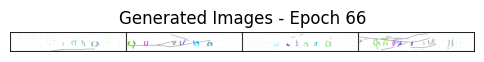

[66/200][0/157]	Loss_D: 2.1019	Loss_G: 0.2408	D(x): 0.1704	D(G(z)): 0.1344 / 0.7994
[66/200][50/157]	Loss_D: 1.3267	Loss_G: 1.8951	D(x): 0.8225	D(G(z)): 0.6585 / 0.1681
[66/200][100/157]	Loss_D: 1.0916	Loss_G: 0.8574	D(x): 0.5124	D(G(z)): 0.3083 / 0.4569
[66/200][150/157]	Loss_D: 1.1315	Loss_G: 1.3014	D(x): 0.6305	D(G(z)): 0.4483 / 0.3062


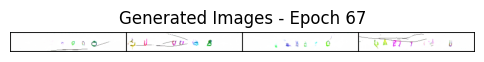

[67/200][0/157]	Loss_D: 0.9629	Loss_G: 1.8800	D(x): 0.7046	D(G(z)): 0.4286 / 0.1794
[67/200][50/157]	Loss_D: 1.1212	Loss_G: 0.6668	D(x): 0.4432	D(G(z)): 0.2062 / 0.5294
[67/200][100/157]	Loss_D: 1.6783	Loss_G: 2.5567	D(x): 0.8751	D(G(z)): 0.7628 / 0.0959
[67/200][150/157]	Loss_D: 1.1503	Loss_G: 2.2195	D(x): 0.7974	D(G(z)): 0.5731 / 0.1319


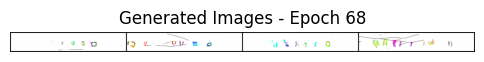

[68/200][0/157]	Loss_D: 1.0051	Loss_G: 0.7909	D(x): 0.5092	D(G(z)): 0.2435 / 0.4785
[68/200][50/157]	Loss_D: 0.9758	Loss_G: 0.9658	D(x): 0.5581	D(G(z)): 0.2890 / 0.4006
[68/200][100/157]	Loss_D: 0.8854	Loss_G: 0.9112	D(x): 0.6355	D(G(z)): 0.3169 / 0.4270
[68/200][150/157]	Loss_D: 1.1858	Loss_G: 0.7141	D(x): 0.4295	D(G(z)): 0.2415 / 0.5175


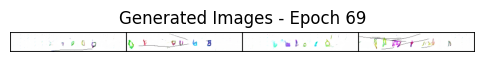

[69/200][0/157]	Loss_D: 1.0012	Loss_G: 0.8170	D(x): 0.5100	D(G(z)): 0.2330 / 0.4788
[69/200][50/157]	Loss_D: 1.5393	Loss_G: 2.4601	D(x): 0.8688	D(G(z)): 0.7276 / 0.1049
[69/200][100/157]	Loss_D: 1.3684	Loss_G: 0.4973	D(x): 0.3182	D(G(z)): 0.1162 / 0.6294
[69/200][150/157]	Loss_D: 1.0006	Loss_G: 0.6600	D(x): 0.5138	D(G(z)): 0.2337 / 0.5417


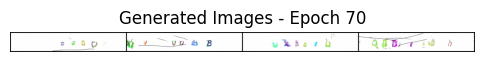

[70/200][0/157]	Loss_D: 1.3414	Loss_G: 0.5686	D(x): 0.3436	D(G(z)): 0.1221 / 0.5883
[70/200][50/157]	Loss_D: 0.9981	Loss_G: 1.0636	D(x): 0.6403	D(G(z)): 0.3844 / 0.3737
[70/200][100/157]	Loss_D: 0.8558	Loss_G: 1.6106	D(x): 0.6876	D(G(z)): 0.3494 / 0.2297
[70/200][150/157]	Loss_D: 1.4432	Loss_G: 2.1067	D(x): 0.9072	D(G(z)): 0.7026 / 0.1478


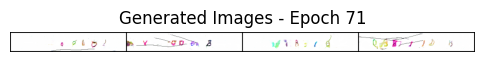

[71/200][0/157]	Loss_D: 1.6654	Loss_G: 0.7122	D(x): 0.2493	D(G(z)): 0.1232 / 0.5645
[71/200][50/157]	Loss_D: 0.8653	Loss_G: 1.1256	D(x): 0.6757	D(G(z)): 0.3383 / 0.3553
[71/200][100/157]	Loss_D: 1.1229	Loss_G: 0.9327	D(x): 0.5293	D(G(z)): 0.3178 / 0.4471
[71/200][150/157]	Loss_D: 1.0949	Loss_G: 1.5726	D(x): 0.6904	D(G(z)): 0.4689 / 0.2348


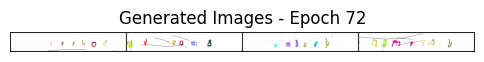

[72/200][0/157]	Loss_D: 1.3406	Loss_G: 0.6481	D(x): 0.3174	D(G(z)): 0.0982 / 0.5593
[72/200][50/157]	Loss_D: 0.9899	Loss_G: 1.0449	D(x): 0.4990	D(G(z)): 0.2081 / 0.3845
[72/200][100/157]	Loss_D: 1.0418	Loss_G: 2.5337	D(x): 0.8572	D(G(z)): 0.5597 / 0.1102
[72/200][150/157]	Loss_D: 0.9012	Loss_G: 1.2859	D(x): 0.6563	D(G(z)): 0.3315 / 0.3156


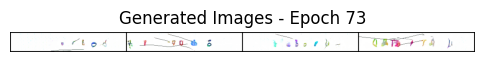

[73/200][0/157]	Loss_D: 1.1039	Loss_G: 2.9138	D(x): 0.7963	D(G(z)): 0.5429 / 0.0849
[73/200][50/157]	Loss_D: 1.1438	Loss_G: 0.6106	D(x): 0.4071	D(G(z)): 0.1486 / 0.5709
[73/200][100/157]	Loss_D: 1.0232	Loss_G: 0.7632	D(x): 0.6297	D(G(z)): 0.3830 / 0.4852
[73/200][150/157]	Loss_D: 0.8879	Loss_G: 0.7024	D(x): 0.5666	D(G(z)): 0.2358 / 0.5263


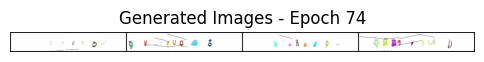

[74/200][0/157]	Loss_D: 0.7057	Loss_G: 1.2229	D(x): 0.7111	D(G(z)): 0.2823 / 0.3345
[74/200][50/157]	Loss_D: 0.9887	Loss_G: 0.7476	D(x): 0.5949	D(G(z)): 0.3441 / 0.5052
[74/200][100/157]	Loss_D: 1.7514	Loss_G: 0.3754	D(x): 0.2553	D(G(z)): 0.0887 / 0.7337
[74/200][150/157]	Loss_D: 1.0728	Loss_G: 1.7748	D(x): 0.8576	D(G(z)): 0.5693 / 0.2031


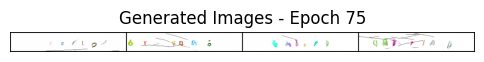

[75/200][0/157]	Loss_D: 0.9811	Loss_G: 1.5471	D(x): 0.7740	D(G(z)): 0.4723 / 0.2807
[75/200][50/157]	Loss_D: 0.9295	Loss_G: 1.5322	D(x): 0.7014	D(G(z)): 0.3974 / 0.2607
[75/200][100/157]	Loss_D: 0.8100	Loss_G: 1.5870	D(x): 0.6739	D(G(z)): 0.2987 / 0.2284
[75/200][150/157]	Loss_D: 1.0250	Loss_G: 0.6822	D(x): 0.4611	D(G(z)): 0.1613 / 0.5263


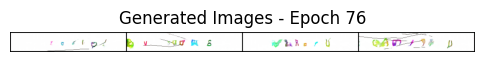

[76/200][0/157]	Loss_D: 0.8651	Loss_G: 1.0823	D(x): 0.7274	D(G(z)): 0.3763 / 0.3784
[76/200][50/157]	Loss_D: 1.1518	Loss_G: 0.6130	D(x): 0.3902	D(G(z)): 0.1185 / 0.5816
[76/200][100/157]	Loss_D: 1.3453	Loss_G: 0.5795	D(x): 0.3335	D(G(z)): 0.1381 / 0.5842
[76/200][150/157]	Loss_D: 0.9326	Loss_G: 1.3658	D(x): 0.8121	D(G(z)): 0.4766 / 0.2990


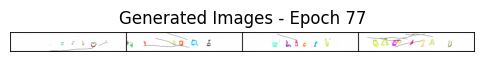

[77/200][0/157]	Loss_D: 1.4138	Loss_G: 3.4354	D(x): 0.9060	D(G(z)): 0.6927 / 0.0426
[77/200][50/157]	Loss_D: 0.8095	Loss_G: 1.8108	D(x): 0.6978	D(G(z)): 0.3229 / 0.2054
[77/200][100/157]	Loss_D: 0.9353	Loss_G: 0.9079	D(x): 0.5443	D(G(z)): 0.2165 / 0.4307
[77/200][150/157]	Loss_D: 0.8921	Loss_G: 0.7989	D(x): 0.6111	D(G(z)): 0.2826 / 0.4953


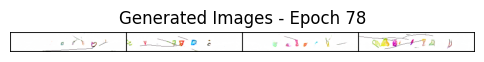

[78/200][0/157]	Loss_D: 1.2201	Loss_G: 0.6671	D(x): 0.3622	D(G(z)): 0.0835 / 0.5794
[78/200][50/157]	Loss_D: 1.0068	Loss_G: 2.4348	D(x): 0.8362	D(G(z)): 0.5152 / 0.1100
[78/200][100/157]	Loss_D: 1.2787	Loss_G: 2.6479	D(x): 0.9180	D(G(z)): 0.6659 / 0.0911
[78/200][150/157]	Loss_D: 1.0868	Loss_G: 1.1613	D(x): 0.6311	D(G(z)): 0.4308 / 0.3403


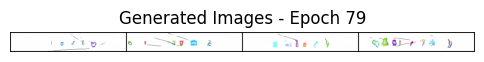

[79/200][0/157]	Loss_D: 1.2205	Loss_G: 0.4604	D(x): 0.4197	D(G(z)): 0.2334 / 0.6576
[79/200][50/157]	Loss_D: 0.9815	Loss_G: 1.2171	D(x): 0.5757	D(G(z)): 0.3078 / 0.3394
[79/200][100/157]	Loss_D: 0.8886	Loss_G: 1.7227	D(x): 0.7765	D(G(z)): 0.4258 / 0.2118
[79/200][150/157]	Loss_D: 1.2499	Loss_G: 0.5867	D(x): 0.3640	D(G(z)): 0.1221 / 0.5852


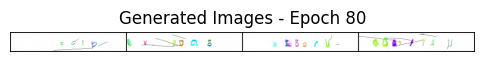

[80/200][0/157]	Loss_D: 0.9720	Loss_G: 2.2478	D(x): 0.8496	D(G(z)): 0.5257 / 0.1330
[80/200][50/157]	Loss_D: 0.8418	Loss_G: 1.1032	D(x): 0.6834	D(G(z)): 0.3307 / 0.3620
[80/200][100/157]	Loss_D: 0.9319	Loss_G: 1.3011	D(x): 0.7503	D(G(z)): 0.4461 / 0.3122
[80/200][150/157]	Loss_D: 0.9720	Loss_G: 1.1916	D(x): 0.5351	D(G(z)): 0.2360 / 0.3329


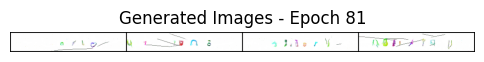

[81/200][0/157]	Loss_D: 1.5093	Loss_G: 2.3195	D(x): 0.9558	D(G(z)): 0.7335 / 0.1283
[81/200][50/157]	Loss_D: 1.0951	Loss_G: 0.8821	D(x): 0.4457	D(G(z)): 0.1632 / 0.4426
[81/200][100/157]	Loss_D: 1.2231	Loss_G: 2.7700	D(x): 0.8851	D(G(z)): 0.6228 / 0.0846
[81/200][150/157]	Loss_D: 0.9218	Loss_G: 1.9060	D(x): 0.8053	D(G(z)): 0.4748 / 0.1906


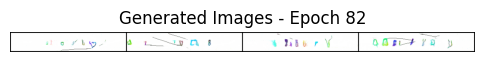

[82/200][0/157]	Loss_D: 1.1105	Loss_G: 1.7120	D(x): 0.8190	D(G(z)): 0.5314 / 0.2325
[82/200][50/157]	Loss_D: 0.9759	Loss_G: 0.7038	D(x): 0.4747	D(G(z)): 0.1176 / 0.5258
[82/200][100/157]	Loss_D: 1.1389	Loss_G: 1.4830	D(x): 0.7183	D(G(z)): 0.5082 / 0.2736
[82/200][150/157]	Loss_D: 1.2591	Loss_G: 2.7657	D(x): 0.8744	D(G(z)): 0.6403 / 0.0931


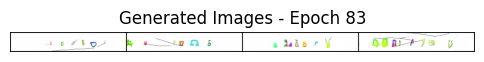

[83/200][0/157]	Loss_D: 0.8560	Loss_G: 1.1188	D(x): 0.5617	D(G(z)): 0.1794 / 0.3939
[83/200][50/157]	Loss_D: 0.7179	Loss_G: 1.9565	D(x): 0.8258	D(G(z)): 0.3802 / 0.1839
[83/200][100/157]	Loss_D: 1.1901	Loss_G: 0.6708	D(x): 0.3839	D(G(z)): 0.1197 / 0.5654
[83/200][150/157]	Loss_D: 1.1029	Loss_G: 0.7171	D(x): 0.4146	D(G(z)): 0.1079 / 0.5367


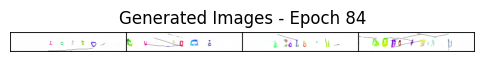

[84/200][0/157]	Loss_D: 1.3048	Loss_G: 0.5936	D(x): 0.3349	D(G(z)): 0.0595 / 0.6159
[84/200][50/157]	Loss_D: 0.8197	Loss_G: 1.2868	D(x): 0.7611	D(G(z)): 0.3788 / 0.3035
[84/200][100/157]	Loss_D: 1.2281	Loss_G: 0.7229	D(x): 0.3597	D(G(z)): 0.0801 / 0.5210
[84/200][150/157]	Loss_D: 1.0668	Loss_G: 0.7821	D(x): 0.4367	D(G(z)): 0.1303 / 0.5153


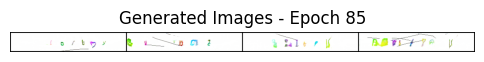

[85/200][0/157]	Loss_D: 0.9944	Loss_G: 0.6309	D(x): 0.4292	D(G(z)): 0.0712 / 0.5613
[85/200][50/157]	Loss_D: 1.0600	Loss_G: 2.2785	D(x): 0.8119	D(G(z)): 0.5295 / 0.1294
[85/200][100/157]	Loss_D: 1.7128	Loss_G: 0.5765	D(x): 0.2312	D(G(z)): 0.0542 / 0.6146
[85/200][150/157]	Loss_D: 1.0790	Loss_G: 1.9537	D(x): 0.8211	D(G(z)): 0.5311 / 0.1858


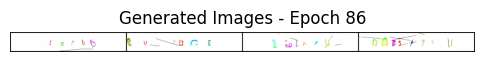

[86/200][0/157]	Loss_D: 0.7209	Loss_G: 1.1528	D(x): 0.7220	D(G(z)): 0.2869 / 0.3481
[86/200][50/157]	Loss_D: 0.8539	Loss_G: 1.0505	D(x): 0.5704	D(G(z)): 0.2024 / 0.3888
[86/200][100/157]	Loss_D: 0.7562	Loss_G: 0.9091	D(x): 0.6345	D(G(z)): 0.2157 / 0.4388
[86/200][150/157]	Loss_D: 0.9328	Loss_G: 1.8793	D(x): 0.7709	D(G(z)): 0.4352 / 0.1903


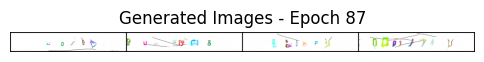

[87/200][0/157]	Loss_D: 1.4365	Loss_G: 2.9156	D(x): 0.9299	D(G(z)): 0.6822 / 0.0694
[87/200][50/157]	Loss_D: 1.2165	Loss_G: 0.4628	D(x): 0.3778	D(G(z)): 0.0775 / 0.6562
[87/200][100/157]	Loss_D: 1.1144	Loss_G: 2.1612	D(x): 0.8038	D(G(z)): 0.5303 / 0.1537
[87/200][150/157]	Loss_D: 0.6492	Loss_G: 1.2662	D(x): 0.7263	D(G(z)): 0.2358 / 0.3340


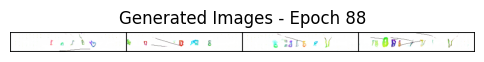

[88/200][0/157]	Loss_D: 2.3823	Loss_G: 0.5454	D(x): 0.1261	D(G(z)): 0.0198 / 0.6163
[88/200][50/157]	Loss_D: 0.8720	Loss_G: 1.4921	D(x): 0.5892	D(G(z)): 0.2155 / 0.2604
[88/200][100/157]	Loss_D: 0.6447	Loss_G: 1.8998	D(x): 0.7483	D(G(z)): 0.2497 / 0.2030
[88/200][150/157]	Loss_D: 0.7272	Loss_G: 1.6838	D(x): 0.7186	D(G(z)): 0.2864 / 0.2197


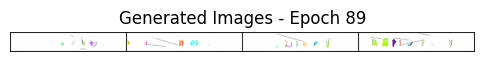

[89/200][0/157]	Loss_D: 0.8197	Loss_G: 2.5726	D(x): 0.7799	D(G(z)): 0.3945 / 0.0970
[89/200][50/157]	Loss_D: 0.6894	Loss_G: 1.3990	D(x): 0.6731	D(G(z)): 0.2129 / 0.2952
[89/200][100/157]	Loss_D: 1.5435	Loss_G: 2.4934	D(x): 0.9093	D(G(z)): 0.7342 / 0.1045
[89/200][150/157]	Loss_D: 0.8296	Loss_G: 1.6528	D(x): 0.6551	D(G(z)): 0.2788 / 0.2322


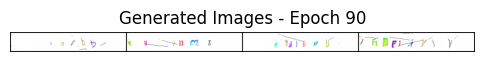

[90/200][0/157]	Loss_D: 0.7437	Loss_G: 1.9728	D(x): 0.7214	D(G(z)): 0.3001 / 0.2052
[90/200][50/157]	Loss_D: 0.6342	Loss_G: 2.0423	D(x): 0.7543	D(G(z)): 0.2616 / 0.1643
[90/200][100/157]	Loss_D: 0.9926	Loss_G: 1.6238	D(x): 0.7104	D(G(z)): 0.4229 / 0.2361
[90/200][150/157]	Loss_D: 0.7280	Loss_G: 1.4354	D(x): 0.6428	D(G(z)): 0.1860 / 0.2915


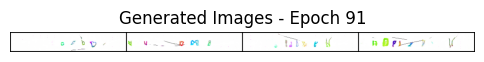

[91/200][0/157]	Loss_D: 0.5442	Loss_G: 2.2759	D(x): 0.7888	D(G(z)): 0.2410 / 0.1324
[91/200][50/157]	Loss_D: 0.7387	Loss_G: 1.9534	D(x): 0.7933	D(G(z)): 0.3457 / 0.1855
[91/200][100/157]	Loss_D: 0.8635	Loss_G: 2.7009	D(x): 0.8723	D(G(z)): 0.4636 / 0.1007
[91/200][150/157]	Loss_D: 1.5650	Loss_G: 0.6724	D(x): 0.2725	D(G(z)): 0.0726 / 0.5445


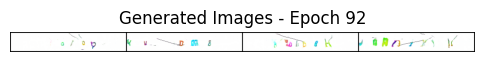

[92/200][0/157]	Loss_D: 0.9323	Loss_G: 0.9973	D(x): 0.5017	D(G(z)): 0.1246 / 0.4442
[92/200][50/157]	Loss_D: 0.7555	Loss_G: 1.2724	D(x): 0.6089	D(G(z)): 0.1661 / 0.3565
[92/200][100/157]	Loss_D: 0.6660	Loss_G: 1.1831	D(x): 0.6365	D(G(z)): 0.1464 / 0.3620
[92/200][150/157]	Loss_D: 0.8115	Loss_G: 1.4874	D(x): 0.5731	D(G(z)): 0.1440 / 0.2880


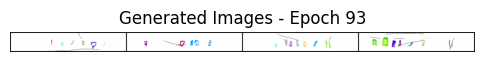

[93/200][0/157]	Loss_D: 0.6474	Loss_G: 1.8558	D(x): 0.7915	D(G(z)): 0.2916 / 0.1998
[93/200][50/157]	Loss_D: 0.9530	Loss_G: 3.0962	D(x): 0.8765	D(G(z)): 0.4995 / 0.0646
[93/200][100/157]	Loss_D: 0.8243	Loss_G: 3.0664	D(x): 0.9105	D(G(z)): 0.4825 / 0.0671
[93/200][150/157]	Loss_D: 0.9112	Loss_G: 1.8796	D(x): 0.8749	D(G(z)): 0.5029 / 0.1855


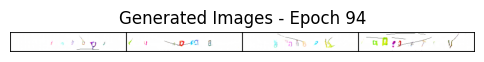

[94/200][0/157]	Loss_D: 1.1087	Loss_G: 3.3148	D(x): 0.9281	D(G(z)): 0.5912 / 0.0521
[94/200][50/157]	Loss_D: 0.7214	Loss_G: 1.9644	D(x): 0.8528	D(G(z)): 0.3937 / 0.1833
[94/200][100/157]	Loss_D: 0.8136	Loss_G: 2.1618	D(x): 0.8286	D(G(z)): 0.4059 / 0.1463
[94/200][150/157]	Loss_D: 0.7402	Loss_G: 1.2354	D(x): 0.6327	D(G(z)): 0.1897 / 0.3554


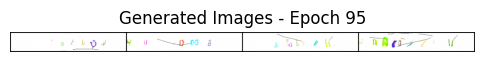

[95/200][0/157]	Loss_D: 0.6274	Loss_G: 1.4233	D(x): 0.7942	D(G(z)): 0.2849 / 0.3508
[95/200][50/157]	Loss_D: 0.7128	Loss_G: 2.1406	D(x): 0.7798	D(G(z)): 0.3235 / 0.1626
[95/200][100/157]	Loss_D: 0.6659	Loss_G: 2.1070	D(x): 0.7830	D(G(z)): 0.3022 / 0.1845
[95/200][150/157]	Loss_D: 0.9380	Loss_G: 2.6871	D(x): 0.8735	D(G(z)): 0.4999 / 0.0923


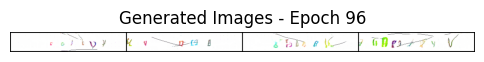

[96/200][0/157]	Loss_D: 0.8351	Loss_G: 3.2345	D(x): 0.9382	D(G(z)): 0.4813 / 0.0610
[96/200][50/157]	Loss_D: 0.7076	Loss_G: 1.4926	D(x): 0.6605	D(G(z)): 0.1983 / 0.3181
[96/200][100/157]	Loss_D: 0.7672	Loss_G: 2.2914	D(x): 0.8761	D(G(z)): 0.4270 / 0.1363
[96/200][150/157]	Loss_D: 0.7246	Loss_G: 1.2988	D(x): 0.6803	D(G(z)): 0.2181 / 0.3461


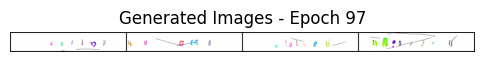

[97/200][0/157]	Loss_D: 0.5479	Loss_G: 1.6061	D(x): 0.7698	D(G(z)): 0.2214 / 0.2847
[97/200][50/157]	Loss_D: 0.6477	Loss_G: 2.7821	D(x): 0.8952	D(G(z)): 0.3788 / 0.0851
[97/200][100/157]	Loss_D: 0.5241	Loss_G: 2.4387	D(x): 0.9001	D(G(z)): 0.3167 / 0.1211
[97/200][150/157]	Loss_D: 0.8590	Loss_G: 2.6369	D(x): 0.9225	D(G(z)): 0.4990 / 0.1141


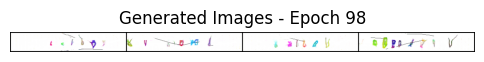

[98/200][0/157]	Loss_D: 0.5989	Loss_G: 1.3521	D(x): 0.6262	D(G(z)): 0.0782 / 0.3158
[98/200][50/157]	Loss_D: 0.8602	Loss_G: 2.4034	D(x): 0.8842	D(G(z)): 0.4681 / 0.1186
[98/200][100/157]	Loss_D: 1.0726	Loss_G: 0.6644	D(x): 0.4442	D(G(z)): 0.0633 / 0.5570
[98/200][150/157]	Loss_D: 0.6110	Loss_G: 3.2563	D(x): 0.8942	D(G(z)): 0.3565 / 0.0619


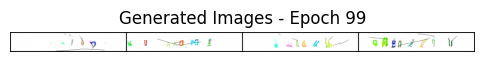

[99/200][0/157]	Loss_D: 1.1918	Loss_G: 0.9402	D(x): 0.3991	D(G(z)): 0.0749 / 0.4576
[99/200][50/157]	Loss_D: 1.0716	Loss_G: 0.6273	D(x): 0.4357	D(G(z)): 0.0807 / 0.5868
[99/200][100/157]	Loss_D: 0.8720	Loss_G: 0.8424	D(x): 0.5031	D(G(z)): 0.0810 / 0.5096
[99/200][150/157]	Loss_D: 0.9676	Loss_G: 3.1368	D(x): 0.8976	D(G(z)): 0.5163 / 0.0656


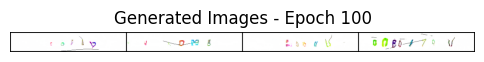

[100/200][0/157]	Loss_D: 0.6072	Loss_G: 1.6889	D(x): 0.7656	D(G(z)): 0.2537 / 0.2810
[100/200][50/157]	Loss_D: 0.6450	Loss_G: 2.5248	D(x): 0.8752	D(G(z)): 0.3673 / 0.1179
[100/200][100/157]	Loss_D: 0.6298	Loss_G: 1.3635	D(x): 0.6791	D(G(z)): 0.1725 / 0.3197
[100/200][150/157]	Loss_D: 2.7332	Loss_G: 2.9669	D(x): 0.8885	D(G(z)): 0.8928 / 0.0748


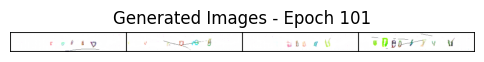

[101/200][0/157]	Loss_D: 1.5718	Loss_G: 0.4668	D(x): 0.3212	D(G(z)): 0.1904 / 0.6764
[101/200][50/157]	Loss_D: 1.8178	Loss_G: 0.5323	D(x): 0.2145	D(G(z)): 0.0634 / 0.6256
[101/200][100/157]	Loss_D: 1.2160	Loss_G: 3.1712	D(x): 0.9014	D(G(z)): 0.6236 / 0.0588
[101/200][150/157]	Loss_D: 2.0838	Loss_G: 0.6090	D(x): 0.1762	D(G(z)): 0.0320 / 0.6098


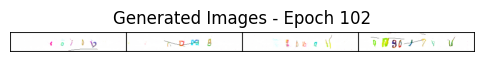

[102/200][0/157]	Loss_D: 1.3175	Loss_G: 0.6422	D(x): 0.3472	D(G(z)): 0.1013 / 0.5679
[102/200][50/157]	Loss_D: 0.7364	Loss_G: 1.3799	D(x): 0.5952	D(G(z)): 0.1216 / 0.3250
[102/200][100/157]	Loss_D: 0.7435	Loss_G: 2.6691	D(x): 0.8672	D(G(z)): 0.4143 / 0.0963
[102/200][150/157]	Loss_D: 0.7194	Loss_G: 0.7505	D(x): 0.6540	D(G(z)): 0.2070 / 0.5246


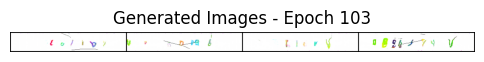

[103/200][0/157]	Loss_D: 0.7934	Loss_G: 2.6831	D(x): 0.8431	D(G(z)): 0.4025 / 0.0984
[103/200][50/157]	Loss_D: 0.6494	Loss_G: 1.7491	D(x): 0.7249	D(G(z)): 0.2309 / 0.2335
[103/200][100/157]	Loss_D: 0.6004	Loss_G: 2.0462	D(x): 0.8762	D(G(z)): 0.3425 / 0.1751
[103/200][150/157]	Loss_D: 0.6454	Loss_G: 2.0977	D(x): 0.8121	D(G(z)): 0.3056 / 0.1899


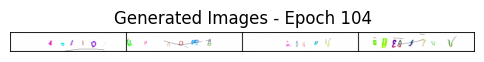

[104/200][0/157]	Loss_D: 0.7216	Loss_G: 3.2130	D(x): 0.9047	D(G(z)): 0.4205 / 0.0531
[104/200][50/157]	Loss_D: 0.7567	Loss_G: 3.0503	D(x): 0.8886	D(G(z)): 0.4302 / 0.0823
[104/200][100/157]	Loss_D: 1.7371	Loss_G: 3.9558	D(x): 0.9703	D(G(z)): 0.7682 / 0.0282
[104/200][150/157]	Loss_D: 1.1807	Loss_G: 0.4596	D(x): 0.3939	D(G(z)): 0.0535 / 0.6625


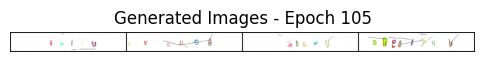

[105/200][0/157]	Loss_D: 0.6114	Loss_G: 1.7732	D(x): 0.7586	D(G(z)): 0.2455 / 0.2179
[105/200][50/157]	Loss_D: 0.5406	Loss_G: 1.4889	D(x): 0.7866	D(G(z)): 0.2249 / 0.2976
[105/200][100/157]	Loss_D: 0.5734	Loss_G: 3.2056	D(x): 0.8754	D(G(z)): 0.3213 / 0.0703
[105/200][150/157]	Loss_D: 1.5163	Loss_G: 4.2387	D(x): 0.9644	D(G(z)): 0.6887 / 0.0258


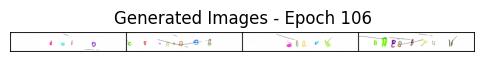

[106/200][0/157]	Loss_D: 0.5731	Loss_G: 3.1086	D(x): 0.9327	D(G(z)): 0.3426 / 0.0687
[106/200][50/157]	Loss_D: 0.5355	Loss_G: 1.6332	D(x): 0.7624	D(G(z)): 0.1926 / 0.2534
[106/200][100/157]	Loss_D: 0.7380	Loss_G: 1.4083	D(x): 0.5738	D(G(z)): 0.0964 / 0.3245
[106/200][150/157]	Loss_D: 0.6857	Loss_G: 3.4273	D(x): 0.9187	D(G(z)): 0.4024 / 0.0558


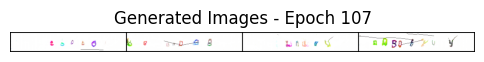

[107/200][0/157]	Loss_D: 0.5830	Loss_G: 1.1115	D(x): 0.6696	D(G(z)): 0.1090 / 0.4294
[107/200][50/157]	Loss_D: 0.9161	Loss_G: 0.7938	D(x): 0.4975	D(G(z)): 0.0790 / 0.5169
[107/200][100/157]	Loss_D: 0.5821	Loss_G: 2.7797	D(x): 0.8719	D(G(z)): 0.3207 / 0.1026
[107/200][150/157]	Loss_D: 0.6417	Loss_G: 2.3076	D(x): 0.7392	D(G(z)): 0.2344 / 0.1406


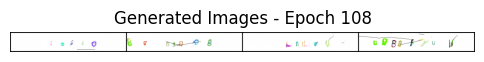

[108/200][0/157]	Loss_D: 0.6669	Loss_G: 3.0767	D(x): 0.8020	D(G(z)): 0.3198 / 0.0912
[108/200][50/157]	Loss_D: 0.7037	Loss_G: 1.0987	D(x): 0.5968	D(G(z)): 0.0609 / 0.4135
[108/200][100/157]	Loss_D: 0.4931	Loss_G: 2.1606	D(x): 0.7830	D(G(z)): 0.1920 / 0.1650
[108/200][150/157]	Loss_D: 0.7976	Loss_G: 3.3208	D(x): 0.9093	D(G(z)): 0.4527 / 0.0599


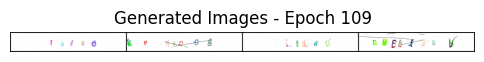

[109/200][0/157]	Loss_D: 0.7340	Loss_G: 1.3241	D(x): 0.6234	D(G(z)): 0.1447 / 0.3842
[109/200][50/157]	Loss_D: 0.5982	Loss_G: 1.6350	D(x): 0.6231	D(G(z)): 0.0572 / 0.2681
[109/200][100/157]	Loss_D: 0.5931	Loss_G: 2.3634	D(x): 0.8228	D(G(z)): 0.2711 / 0.1370
[109/200][150/157]	Loss_D: 0.5112	Loss_G: 2.9103	D(x): 0.8864	D(G(z)): 0.2920 / 0.0998


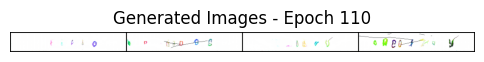

[110/200][0/157]	Loss_D: 0.9382	Loss_G: 4.1411	D(x): 0.9380	D(G(z)): 0.5280 / 0.0263
[110/200][50/157]	Loss_D: 0.5355	Loss_G: 2.4026	D(x): 0.8085	D(G(z)): 0.2391 / 0.1225
[110/200][100/157]	Loss_D: 1.0362	Loss_G: 0.7504	D(x): 0.4716	D(G(z)): 0.0708 / 0.5614
[110/200][150/157]	Loss_D: 0.4562	Loss_G: 2.0691	D(x): 0.7549	D(G(z)): 0.1151 / 0.1833


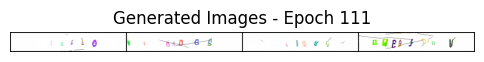

[111/200][0/157]	Loss_D: 1.5860	Loss_G: 0.8675	D(x): 0.2936	D(G(z)): 0.0266 / 0.5431
[111/200][50/157]	Loss_D: 0.5935	Loss_G: 1.6018	D(x): 0.6317	D(G(z)): 0.0394 / 0.2885
[111/200][100/157]	Loss_D: 0.6313	Loss_G: 1.8382	D(x): 0.9062	D(G(z)): 0.3723 / 0.2077
[111/200][150/157]	Loss_D: 0.6373	Loss_G: 2.4768	D(x): 0.8865	D(G(z)): 0.3673 / 0.1215


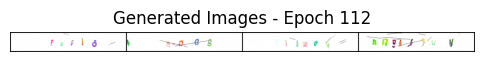

[112/200][0/157]	Loss_D: 0.6714	Loss_G: 3.3012	D(x): 0.9520	D(G(z)): 0.4127 / 0.0685
[112/200][50/157]	Loss_D: 0.5301	Loss_G: 2.5333	D(x): 0.8361	D(G(z)): 0.2491 / 0.1229
[112/200][100/157]	Loss_D: 0.5137	Loss_G: 1.8425	D(x): 0.7791	D(G(z)): 0.1837 / 0.2000
[112/200][150/157]	Loss_D: 0.5897	Loss_G: 1.3320	D(x): 0.6740	D(G(z)): 0.1139 / 0.3210


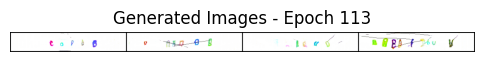

[113/200][0/157]	Loss_D: 0.6472	Loss_G: 3.0287	D(x): 0.8585	D(G(z)): 0.3461 / 0.0756
[113/200][50/157]	Loss_D: 0.5982	Loss_G: 3.8738	D(x): 0.8964	D(G(z)): 0.3462 / 0.0353
[113/200][100/157]	Loss_D: 0.3457	Loss_G: 3.1967	D(x): 0.9380	D(G(z)): 0.2222 / 0.0771
[113/200][150/157]	Loss_D: 0.5031	Loss_G: 2.5251	D(x): 0.7699	D(G(z)): 0.1688 / 0.1593


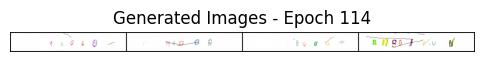

[114/200][0/157]	Loss_D: 0.6567	Loss_G: 2.0138	D(x): 0.7998	D(G(z)): 0.2733 / 0.1880
[114/200][50/157]	Loss_D: 0.8154	Loss_G: 1.1295	D(x): 0.5641	D(G(z)): 0.1458 / 0.4026
[114/200][100/157]	Loss_D: 0.5275	Loss_G: 3.8066	D(x): 0.8682	D(G(z)): 0.2690 / 0.0375
[114/200][150/157]	Loss_D: 0.8179	Loss_G: 0.9388	D(x): 0.5754	D(G(z)): 0.1515 / 0.4722


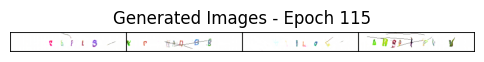

[115/200][0/157]	Loss_D: 0.6463	Loss_G: 1.3968	D(x): 0.8199	D(G(z)): 0.2994 / 0.3141
[115/200][50/157]	Loss_D: 0.6773	Loss_G: 3.0608	D(x): 0.9299	D(G(z)): 0.4018 / 0.0967
[115/200][100/157]	Loss_D: 0.5082	Loss_G: 2.5442	D(x): 0.8470	D(G(z)): 0.2461 / 0.1262
[115/200][150/157]	Loss_D: 0.8266	Loss_G: 2.6238	D(x): 0.9060	D(G(z)): 0.4714 / 0.1019


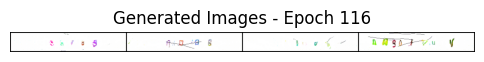

[116/200][0/157]	Loss_D: 0.6533	Loss_G: 1.5555	D(x): 0.6524	D(G(z)): 0.1166 / 0.2722
[116/200][50/157]	Loss_D: 0.6323	Loss_G: 0.8331	D(x): 0.6340	D(G(z)): 0.1046 / 0.5127
[116/200][100/157]	Loss_D: 1.0053	Loss_G: 3.1142	D(x): 0.9464	D(G(z)): 0.5401 / 0.0819
[116/200][150/157]	Loss_D: 0.4758	Loss_G: 2.1084	D(x): 0.7273	D(G(z)): 0.1061 / 0.2313


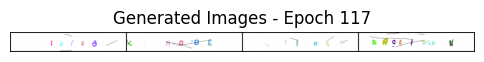

[117/200][0/157]	Loss_D: 0.6976	Loss_G: 3.6678	D(x): 0.8853	D(G(z)): 0.3726 / 0.0549
[117/200][50/157]	Loss_D: 0.5245	Loss_G: 1.8021	D(x): 0.7906	D(G(z)): 0.2208 / 0.2389
[117/200][100/157]	Loss_D: 0.5347	Loss_G: 3.3672	D(x): 0.9030	D(G(z)): 0.3175 / 0.0533
[117/200][150/157]	Loss_D: 0.5487	Loss_G: 3.2550	D(x): 0.9109	D(G(z)): 0.3340 / 0.0632


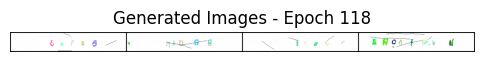

[118/200][0/157]	Loss_D: 1.2273	Loss_G: 0.0042	D(x): 0.4085	D(G(z)): 0.0484 / 0.9958
[118/200][50/157]	Loss_D: 0.7335	Loss_G: 3.5426	D(x): 0.9170	D(G(z)): 0.4250 / 0.0547
[118/200][100/157]	Loss_D: 0.8412	Loss_G: 3.7075	D(x): 0.9118	D(G(z)): 0.4658 / 0.0437
[118/200][150/157]	Loss_D: 0.6668	Loss_G: 4.0931	D(x): 0.9543	D(G(z)): 0.4147 / 0.0313


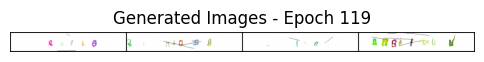

[119/200][0/157]	Loss_D: 0.9536	Loss_G: 1.6389	D(x): 0.5183	D(G(z)): 0.1311 / 0.2799
[119/200][50/157]	Loss_D: 0.4805	Loss_G: 2.0017	D(x): 0.7524	D(G(z)): 0.1428 / 0.2004
[119/200][100/157]	Loss_D: 0.4260	Loss_G: 3.0599	D(x): 0.8867	D(G(z)): 0.2289 / 0.0754
[119/200][150/157]	Loss_D: 0.3946	Loss_G: 2.0827	D(x): 0.7813	D(G(z)): 0.1035 / 0.1921


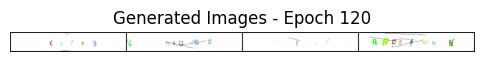

[120/200][0/157]	Loss_D: 0.2961	Loss_G: 2.7910	D(x): 0.8681	D(G(z)): 0.1277 / 0.0973
[120/200][50/157]	Loss_D: 1.0504	Loss_G: 3.5693	D(x): 0.9371	D(G(z)): 0.5647 / 0.0504
[120/200][100/157]	Loss_D: 0.6699	Loss_G: 1.5518	D(x): 0.6412	D(G(z)): 0.1075 / 0.3191
[120/200][150/157]	Loss_D: 0.3335	Loss_G: 2.6724	D(x): 0.8891	D(G(z)): 0.1736 / 0.1147


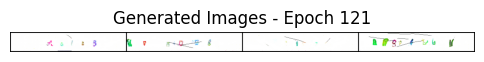

[121/200][0/157]	Loss_D: 0.5856	Loss_G: 2.9745	D(x): 0.7349	D(G(z)): 0.2000 / 0.1035
[121/200][50/157]	Loss_D: 0.3810	Loss_G: 1.9317	D(x): 0.7970	D(G(z)): 0.1166 / 0.1982
[121/200][100/157]	Loss_D: 0.4439	Loss_G: 3.7978	D(x): 0.9122	D(G(z)): 0.2498 / 0.0480
[121/200][150/157]	Loss_D: 0.5958	Loss_G: 1.2843	D(x): 0.6474	D(G(z)): 0.0965 / 0.4086


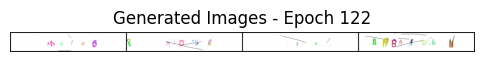

[122/200][0/157]	Loss_D: 0.3662	Loss_G: 2.3516	D(x): 0.8564	D(G(z)): 0.1653 / 0.1515
[122/200][50/157]	Loss_D: 0.4060	Loss_G: 3.6229	D(x): 0.9480	D(G(z)): 0.2613 / 0.0445
[122/200][100/157]	Loss_D: 1.6924	Loss_G: 0.8485	D(x): 0.2561	D(G(z)): 0.0340 / 0.5021
[122/200][150/157]	Loss_D: 0.8784	Loss_G: 3.1815	D(x): 0.9403	D(G(z)): 0.4966 / 0.0623


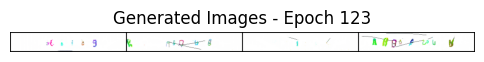

[123/200][0/157]	Loss_D: 0.3822	Loss_G: 2.2682	D(x): 0.7782	D(G(z)): 0.0743 / 0.1614
[123/200][50/157]	Loss_D: 0.5221	Loss_G: 3.0894	D(x): 0.9123	D(G(z)): 0.2968 / 0.0772
[123/200][100/157]	Loss_D: 3.8372	Loss_G: 0.2874	D(x): 0.0377	D(G(z)): 0.0153 / 0.7769
[123/200][150/157]	Loss_D: 0.4835	Loss_G: 1.5273	D(x): 0.7329	D(G(z)): 0.1105 / 0.2989


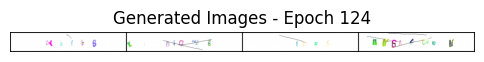

[124/200][0/157]	Loss_D: 1.0002	Loss_G: 4.2892	D(x): 0.9812	D(G(z)): 0.5516 / 0.0273
[124/200][50/157]	Loss_D: 0.5601	Loss_G: 2.7126	D(x): 0.6979	D(G(z)): 0.0978 / 0.1280
[124/200][100/157]	Loss_D: 0.6909	Loss_G: 0.9667	D(x): 0.6479	D(G(z)): 0.1439 / 0.4777
[124/200][150/157]	Loss_D: 0.2719	Loss_G: 2.1796	D(x): 0.8566	D(G(z)): 0.0833 / 0.1629


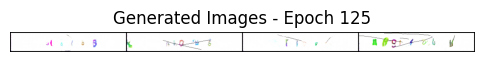

[125/200][0/157]	Loss_D: 0.6993	Loss_G: 3.6917	D(x): 0.9413	D(G(z)): 0.3837 / 0.0611
[125/200][50/157]	Loss_D: 0.7562	Loss_G: 2.5409	D(x): 0.9267	D(G(z)): 0.4272 / 0.1330
[125/200][100/157]	Loss_D: 0.4230	Loss_G: 2.6573	D(x): 0.8598	D(G(z)): 0.1918 / 0.0997
[125/200][150/157]	Loss_D: 0.3903	Loss_G: 1.9764	D(x): 0.7721	D(G(z)): 0.0940 / 0.2408


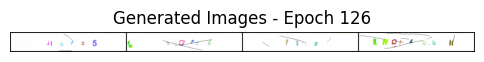

[126/200][0/157]	Loss_D: 0.3374	Loss_G: 3.2255	D(x): 0.8897	D(G(z)): 0.1675 / 0.0857
[126/200][50/157]	Loss_D: 1.3040	Loss_G: 4.5807	D(x): 0.9580	D(G(z)): 0.6305 / 0.0203
[126/200][100/157]	Loss_D: 0.9046	Loss_G: 0.9611	D(x): 0.5060	D(G(z)): 0.0415 / 0.5194
[126/200][150/157]	Loss_D: 0.6389	Loss_G: 1.8336	D(x): 0.6802	D(G(z)): 0.1370 / 0.2842


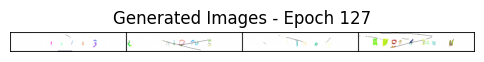

[127/200][0/157]	Loss_D: 0.3746	Loss_G: 2.1251	D(x): 0.8075	D(G(z)): 0.1197 / 0.1727
[127/200][50/157]	Loss_D: 0.3302	Loss_G: 2.9303	D(x): 0.8265	D(G(z)): 0.1012 / 0.0954
[127/200][100/157]	Loss_D: 0.7528	Loss_G: 3.3918	D(x): 0.8571	D(G(z)): 0.3788 / 0.0639
[127/200][150/157]	Loss_D: 1.6191	Loss_G: 0.2391	D(x): 0.2773	D(G(z)): 0.0713 / 0.8141


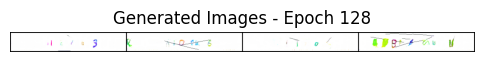

[128/200][0/157]	Loss_D: 1.5279	Loss_G: 0.3729	D(x): 0.3115	D(G(z)): 0.0595 / 0.7365
[128/200][50/157]	Loss_D: 0.4775	Loss_G: 2.9692	D(x): 0.9676	D(G(z)): 0.3323 / 0.1021
[128/200][100/157]	Loss_D: 0.6823	Loss_G: 4.1402	D(x): 0.9258	D(G(z)): 0.4070 / 0.0372
[128/200][150/157]	Loss_D: 0.5464	Loss_G: 1.3891	D(x): 0.6919	D(G(z)): 0.0964 / 0.3602


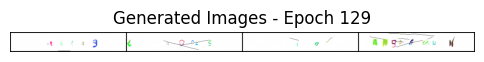

[129/200][0/157]	Loss_D: 0.4811	Loss_G: 1.7901	D(x): 0.7543	D(G(z)): 0.1377 / 0.2280
[129/200][50/157]	Loss_D: 0.6073	Loss_G: 3.1609	D(x): 0.9603	D(G(z)): 0.3853 / 0.0813
[129/200][100/157]	Loss_D: 0.3913	Loss_G: 2.7135	D(x): 0.7940	D(G(z)): 0.1047 / 0.1246
[129/200][150/157]	Loss_D: 0.4046	Loss_G: 1.8412	D(x): 0.8368	D(G(z)): 0.1703 / 0.2464


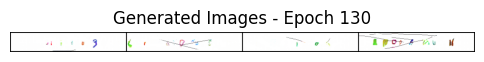

[130/200][0/157]	Loss_D: 0.4456	Loss_G: 2.4219	D(x): 0.7757	D(G(z)): 0.1176 / 0.1537
[130/200][50/157]	Loss_D: 0.6091	Loss_G: 0.9147	D(x): 0.6592	D(G(z)): 0.1121 / 0.4947
[130/200][100/157]	Loss_D: 0.3172	Loss_G: 2.2295	D(x): 0.8932	D(G(z)): 0.1646 / 0.1932
[130/200][150/157]	Loss_D: 0.5702	Loss_G: 3.6991	D(x): 0.9383	D(G(z)): 0.3478 / 0.0392


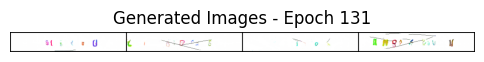

[131/200][0/157]	Loss_D: 0.8126	Loss_G: 3.3972	D(x): 0.9667	D(G(z)): 0.4585 / 0.0624
[131/200][50/157]	Loss_D: 0.3832	Loss_G: 2.6554	D(x): 0.9702	D(G(z)): 0.2550 / 0.1039
[131/200][100/157]	Loss_D: 0.3906	Loss_G: 1.5921	D(x): 0.8375	D(G(z)): 0.1629 / 0.3017
[131/200][150/157]	Loss_D: 0.4418	Loss_G: 1.3157	D(x): 0.7268	D(G(z)): 0.0622 / 0.3541


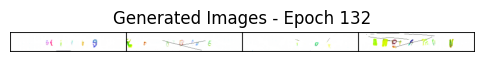

[132/200][0/157]	Loss_D: 0.4330	Loss_G: 3.5956	D(x): 0.9441	D(G(z)): 0.2771 / 0.0513
[132/200][50/157]	Loss_D: 0.7061	Loss_G: 1.4898	D(x): 0.6094	D(G(z)): 0.0760 / 0.3009
[132/200][100/157]	Loss_D: 1.1445	Loss_G: 0.8992	D(x): 0.4208	D(G(z)): 0.0281 / 0.5158
[132/200][150/157]	Loss_D: 0.4744	Loss_G: 3.2198	D(x): 0.9618	D(G(z)): 0.3033 / 0.0810


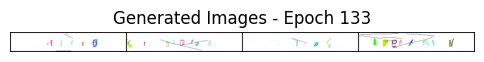

[133/200][0/157]	Loss_D: 0.4037	Loss_G: 1.7474	D(x): 0.8145	D(G(z)): 0.1457 / 0.2719
[133/200][50/157]	Loss_D: 0.2953	Loss_G: 1.6335	D(x): 0.8565	D(G(z)): 0.1099 / 0.2620
[133/200][100/157]	Loss_D: 0.9837	Loss_G: 1.2309	D(x): 0.5893	D(G(z)): 0.2885 / 0.3569
[133/200][150/157]	Loss_D: 0.3444	Loss_G: 2.6932	D(x): 0.8798	D(G(z)): 0.1632 / 0.1227


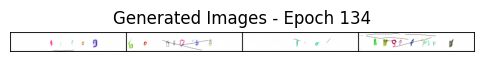

[134/200][0/157]	Loss_D: 0.4931	Loss_G: 1.9648	D(x): 0.7796	D(G(z)): 0.1584 / 0.2354
[134/200][50/157]	Loss_D: 0.4001	Loss_G: 2.8513	D(x): 0.8437	D(G(z)): 0.1654 / 0.0881
[134/200][100/157]	Loss_D: 0.3978	Loss_G: 3.2220	D(x): 0.8594	D(G(z)): 0.1912 / 0.0785
[134/200][150/157]	Loss_D: 1.0463	Loss_G: 4.8428	D(x): 0.9735	D(G(z)): 0.5526 / 0.0139


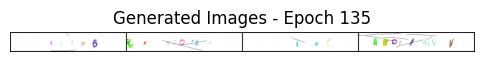

[135/200][0/157]	Loss_D: 0.4027	Loss_G: 1.2977	D(x): 0.7585	D(G(z)): 0.0629 / 0.3582
[135/200][50/157]	Loss_D: 0.8194	Loss_G: 3.5600	D(x): 0.9769	D(G(z)): 0.4873 / 0.0659


KeyboardInterrupt: 

In [13]:
# Training Loop
# Number of training epochs
num_epochs = 200

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        for _ in range(2): #double update
            netG.zero_grad()
            label.fill_(real_label)  # fake labels are real for generator cost
            # Since we just updated D, perform another forward pass of all-fake batch through D
            # Generate new fake images
            noise = torch.randn(b_size, nz, 1, 1, device=device)
            fake = netG(noise)
            output = netD(fake).view(-1)
            # Calculate G's loss based on this output
            errG = criterion(output, label)
            # Calculate gradients for G
            errG.backward()
            D_G_z2 = output.mean().item()
            # Update G
            optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

    # Display a generated image after each epoch
    with torch.no_grad():
        fake_sample = netG(fixed_noise).detach().cpu()
    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.title(f"Generated Images - Epoch {epoch+1}")
    plt.imshow(np.transpose(vutils.make_grid(fake_sample[:4], padding=2, normalize=True), (1,2,0)))
    plt.show()

### Plot Training Generator and Discriminator loss

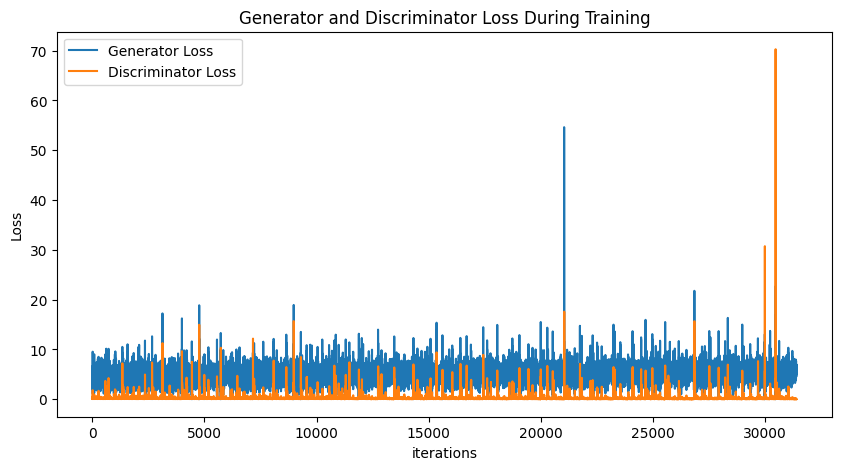

In [37]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="Generator Loss")
plt.plot(D_losses,label="Discriminator Loss")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

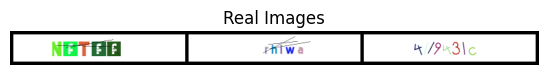

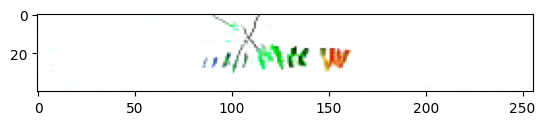

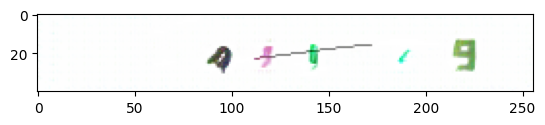

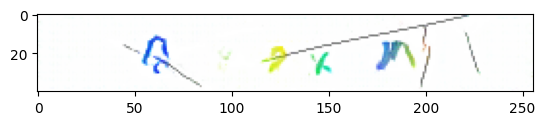

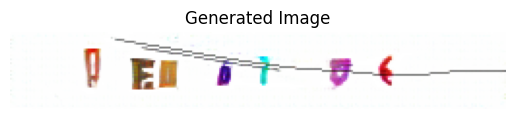

In [31]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:3], padding=5, normalize=True).cpu(),(1,2,0)))
plt.show()

def generate_fake_image():
    # Make sure the generator is in eval mode
    netG.eval()
    
    # Generate a single latent vector
    noise = torch.randn(1, nz, 1, 1, device=device)
    
    # Generate fake image
    with torch.no_grad():
        fake_img = netG(noise).cpu()  # shape: [1, C, H, W]
    
    # Convert to numpy for plotting
    img = fake_img[0]  # remove batch dimension
    np_img = np.transpose(img, (1, 2, 0))  # [H, W, C]
    
    # Rescale from [-1,1] -> [0,1] for display
    np_img = (np_img + 1) / 2.0
    
    # If grayscale, remove channel dimension
    if np_img.shape[2] == 1:
        np_img = np_img[:, :, 0]
        plt.imshow(np_img, cmap='gray')
    else:
        plt.imshow(np_img)
    
    plt.axis('off')
    plt.title("Generated Image")
    plt.show()

for i in range(3):
    noise = torch.randn(1, nz, 1, 1, device=device)
    fake = netG(noise).detach().cpu()
    plt.imshow(np.transpose((fake[0] + 1)/2, (1,2,0)))
    plt.show()

generate_fake_image()

In [34]:
# Save Generator weights
torch.save(netG.state_dict(), "generator.pth")

# Save Discriminator weights
torch.save(netD.state_dict(), "discriminator.pth")